# Riyadh Grocery Demand
## A Backtested Forecasting Report

**Author:** Abdulwahab Mohammed Ali Alnassar  
**Programme:** SDAIA Academy — Time Series Forecasting for AI Systems  
**Cohort dates:** Not supplied — add the actual dates before submission.  
**Series:** Riyadh / Grocery • daily units sold • **synthetic course data**

This notebook turns one raw time series into an evaluated 28-day forecast. It compares
**Seasonal Naive, Holt-Winters, and LightGBM**, tests them on five expanding-window
folds, calibrates uncertainty on later data, and evaluates a final untouched period.

**تشغيل سريع:** ارفع هذا الملف إلى Google Colab، اختر CPU، ثم **Runtime → Run all**.
البيانات مضمّنة، ولا تحتاج ترفع ملفات ثانية أو تضيف API key. الشرح والنتائج بالإنجليزية
لتناسب متطلبات الدورة، مع ملاحظات عربية للمساعدة.

**Submission notes:** All seven requested analysis sections are here. README,
technical documentation, and a GitHub submission guide accompany the project.
Actual cohort dates and publication under your GitHub account remain account-specific
submission steps; this notebook does not pretend those have already happened.

Course brief: [Capstone: A Backtested Forecasting Report](https://mohammadyusif.github.io/time-series-forecasting-ai-systems/capstone.html).
The site's exact point weights/pass mark are labelled **draft**. No grade is claimed.

### Executive summary — actual saved run

The study uses **1,096 synthetic daily observations**, with five model-selection
origins, six later calibration origins, and one untouched 28-day test. The
prespecified selection rule chooses **Seasonal Naive**: its pooled validation WAPE is
**26.13%**, compared with
28.03% for LightGBM and
28.11% for Holt-Winters.

On the final test, the selected procedure achieves **MAE 57.75
units/day**, **RMSE 68.42**, **WAPE 9.21%**,
and **MASE 0.649**. Its nominal 90% interval covers
**27/28 days (96.43%)**, with a mean width of
**344.00 units/day**. Width matters: these are
fairly broad intervals, not proof of near-perfect certainty.

**The important qualification:** LightGBM has the lowest final-test WAPE
(6.91%), but it did not win the earlier selection
backtest. We do not replace the frozen winner after looking at that one test.
Seasonal Naive is the current simple operational candidate; LightGBM remains a
challenger for a broader seasonal evaluation. No model is established as production
ready, particularly given the severe validation spike in fold 3.

**Execution evidence:** 16 code cells completed, with
10 captured charts and zero execution errors in a fresh
local IPython process. The unchanged setup/data/model cells were actually run.
This verification was local, not an authenticated Google Colab session. All
saved-run interpretations refer to the included data and configuration; review
them if you change either.

## 0. Environment and study design

The first cell installs the notebook's actual dependencies in the active Python
runtime. A CPU is sufficient. A seed is fixed and LightGBM uses two threads.
The setup accepts compatible package ranges; the exact executed versions are saved
at the end for reproducibility. The delivered copy already contains real outputs.

In [1]:
import subprocess
import sys
from importlib import metadata

REQUIREMENTS = [
    "numpy>=1.26,<3", "pandas>=2.2,<3", "scipy>=1.12,<2",
    "scikit-learn>=1.5,<2", "statsmodels>=0.14.4,<0.16",
    "lightgbm>=4.6,<5", "matplotlib>=3.8,<4", "ipython>=8",
]
subprocess.run([sys.executable, "-m", "pip", "install", "--quiet",
                "--disable-pip-version-check", *REQUIREMENTS], check=True)
print("Environment ready. CPU execution; no API keys or Drive mount required.")
for package in ["numpy", "pandas", "scipy", "scikit-learn", "statsmodels", "lightgbm", "matplotlib"]:
    print(f"{package}: {metadata.version(package)}")

Environment ready. CPU execution; no API keys or Drive mount required.
numpy: 2.3.5
pandas: 2.2.3
scipy: 1.17.0
scikit-learn: 1.8.0
statsmodels: 0.15.0
lightgbm: 4.7.0
matplotlib: 3.10.8


In [2]:
import base64
import gzip
import hashlib
import io
import json
import math
import platform
import shutil
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown, FileLink
from lightgbm import LGBMRegressor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

SEED = 42
HORIZON = 28
PERIOD = 7
N_SELECTION_FOLDS = 5
N_CALIBRATION_FOLDS = 6
ALPHA = 0.10
COMPLEXITY_TOLERANCE = 0.02  # 2% relative WAPE tolerance, fixed before testing.
EPOCH = pd.Timestamp("2023-01-01")
MODELS = ["Seasonal Naive", "Holt-Winters", "LightGBM"]
np.random.seed(SEED)
OUT = Path("capstone_outputs")
OUT.mkdir(exist_ok=True)
COLORS = {"Seasonal Naive": "#87939c", "Holt-Winters": "#137b80", "LightGBM": "#cd793a"}
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.18, "font.size": 10,
                     "axes.titleweight": "bold", "figure.facecolor": "white"})

def save_figure(fig, filename):
    fig.savefig(OUT / filename, bbox_inches="tight", dpi=140)
    plt.show()
    plt.close(fig)

print(f"Forecast horizon = {HORIZON} days; nominal interval coverage = {1-ALPHA:.0%}.")

Forecast horizon = 28 days; nominal interval coverage = 90%.


## 1. Raw data, decomposition, and diagnostics

### 1.1 Provenance and validation

The data come from the course's `retail_demand.csv`, pinned to commit
`0acb110628250c5efec9dd2b3d5c0b46401ebdee`. Only the **Riyadh / Grocery** pair is selected.
An exact CSV snapshot of that pair is embedded below, so this notebook can run by
itself after package installation. The original four columns are retained; no values
are generated or cleaned retrospectively.

[Immutable source CSV](https://raw.githubusercontent.com/MohammadYusif/time-series-forecasting-ai-systems/0acb110628250c5efec9dd2b3d5c0b46401ebdee/data/retail_demand.csv)

**Synthetic-data disclosure:** The locations label a designed teaching example.
The demand levels, holidays, promotions, and all scores below do not describe a real business.
The synthetic generator's hidden shock realizations are never used as features.

In [3]:
# @title Load the embedded course-data snapshot (expand to inspect)
SOURCE_COMMIT = "0acb110628250c5efec9dd2b3d5c0b46401ebdee"
SOURCE_URL = "https://raw.githubusercontent.com/MohammadYusif/time-series-forecasting-ai-systems/" + SOURCE_COMMIT + "/data/retail_demand.csv"
ORIGINAL_DATA_SHA256 = "08738f5573c1b85c5792ffc18f4308a91666e8bdb1a13e86f8fe898fa1f85362"
SUBSET_SHA256 = "b19ad57eebc2ee88fc1508d8bc5312a1346a16d1166ead5b91ad0bfe7a8347d3"
DATA_GZIP_BASE64 = "H4sIAAAAAAACA4Wd3a5mqXGGz3MtE2sBVfxcQc5zA5HlGTkjRR5p7Bz47tOteH/rfYcHWuqDluqDBUUVFMUD++c//+OXn37/5a+//va3n/7y7f9//e33f/70v3/79R9//6+///Y/P/9bfWr796d8+/fTf/76zz///N8//cfvv/3ll28/GnX+6Xnl9Y/ybKnytslLqDw2eVr53OS9qLz/Ud7D2je29pem8rnJ/ftrb7/WX569/9q/sukvn6XyXX9p9W/666b/sulvzK7yTX99Pirf9BdeftNfL1Z+018u1V/Z9Wf112fvn8k3/a1Q/dVNf2OYfNdfGyrf7W/o+NXd/oaV3+3P7L+Ovf/Wvt3+VlX5pr/5qH7arr9H29fKTV7Bv0O+X8G/dXwq+Pcf6t/0O8X/K/j3bEXlfdefld/1u6z8bp+9qXzTb+9a/+7fXey7gn/PpfrZ/Xs21S/4t/hXBf/W+bWCf+v8UcG/e1j/YH40+aa/Vaz+3T6n6n/371HUPnb/9vHd/dvHF/w7Vb+7f/ep+tv9e4Xax+7fM638Pj/2pfK5t+/tfwP/672rHPwvVL71fzwm3/q/2lL57n9jqnzvf6kqH/v8lCrf+//Y99dt/mjgfyObyvf1YWn9u/+NsPJ7fDK1/7v/9VFUvq+voeO3+5/OP43W12X1z92/rH3rtv43Wl9T7WP3v14fldf7+O3+N4bVf/W/Bv43l32/7/Wr/YH/Nasf7M/k6xafNlpfzX729TXXa78B/r1kfQvw7zGayvf5bVj9u35zqXy3T+lfUPws61OAf5ciBhbg4CV76g/W/oOqTdhdvBSZg4LW2KE63H18NdXh7uPlCe3k7uTfmmgt2LRYZtgPOtRgn9j1+ExV0+7opVYdyd3TyyOhQpCrN/0CuHox+R6qmJbA1ad9P+6mVMEU1ZQrhHo6jBBKm6nvrp7D+reHKqmW3GCpec0swZVzDpXX21KStBUW/SZthZuV3/U3rHy/uUHSVliWqqRQWZbSpK2wfR+2wuLnSVvh1PoLLDVWf7tt9RK3wlZ+19+j/YelOlX/uwvrUp64Fbbv76GOhJJJ/iv+leC/w/QHoXJX+6xgf9r/3X9j6fiB/z7af/DfZfLd/rrqd/ff2ax9u/2Zfe/+G+Z/sFQ/r7yTf0eqHOwzVA72OVS+26fYX6dUl8yfnbbCZal83Py3k39Xq3/d7KNTKD5Uf7t/jzD5bp+1qXy3z2bf3+fHeFQOW2EdH9gK2/gX2MpY/Xuqppj8murq4N+xTA72qfoB/7b2wVa4av93/55N7XP37yFhVif/9vphflT/gfW5qv53/1b/7eDfKfP7oFS1zC+D/FdSyYPWZ+nfAP8NiU8G+a/EN4P8t1r7rvobP0hVD/DfIfYxMFWt34f1uWr7d/+N0VXedvvW9sFWWuavAf6r8eUA/9VUxwD/jWn1z11u7YP5T8vv/puh3wf/XWpfEF9Xk+/+a+2HVHVR/UOqumj/KqT67ftgf6p/2EpX9b8K9qf+AVvpofXD+iztn7Q+S/8n+HeklW+39W9S/C3xywT/HmK/E/x7SCplgn+rf0xan0tROcQ/Wn+B9UXbB/7t5fdURFX9lmuqdWKqWtsP67Osv5Pi72L1j1v8M9G/rf7dPpvqn/bPQ+UwP6p+6nV+nBR/P2pf9RrfTPJvWZ8mHUXZ+IB/L+vfvB0FTVqfQ/UP6/Nj8nKz/0X+LfH9ovVb9s+LUmVh9cct/lwYf3eVw/7Qvj9u47fIvyU+XpQKl/zCoqOoqf0rP9AvrN9T+wfrd9r3wb+XyvN2VLVo/Tb9QSp86viAfw8rv9tnVf1S/K317/6t/rsw/rb64ajZyscNVVjg3zGsffv6LajBolS493+PH739u/66fp9S4R/9l4eOst78xHc5rM8m3+3vjY++y/f427+/6+/1/+/yXX/v/uC7HObHR+VwlGzfB/sbIof1ObT/4L9Fvw/++87/3+UQ31j9cVkfvsvzEv9/l4P9mXyPb4rJd/99rP27/h4tD/47tDygIkP7t/vvMvsA/w21jwr5Gyuf9/6B/775n+/y3f4ea/8ef08rD/uXJnLIj9n4wvos/kUoWLyoRCEULF7UqiAKVlPlcNQ6Vb7nH9/1pxAK1t74phAKFs36t9tn2vdhfnxETv6t/SswP6p+ID+2TL7Pj4+2f/fveOPvQihYDNUf+LfpD+LvZv2fl/xKIRRMUJdScH3W/sH6/Kj9Ufxt9bfL+lkIBdP5hVAwOV8riIKF9n/3b1lfC6FgYfYB67PZB8Tf7/6pVNw/T5XXC8pQEPV649NCqFc+ReWwPofK+2X/Xgj1im7fv6GIhVCv8caXBVGvd39ZCPVS/yHUS/K7hVAvOf8rhHqFtR/W56L6g/h66fgC6lWtffOSvyyEekn8Xwj1ykfrh/3zMPkNJS4Vz5+tfNz7B/vnrvqr/e4/4L9L7YfOn9X+YX02+4bz52lyyG//a3yCUe1P/i4Y1Y4v1C4Y1f6gMnFAtYvJ9/mxm3w/ny7Wvv38pVr79vXlK38djGp/5uc4oNpD9VfO539xQLW9fNsxFSsfR5QuGNX+8AXBqHZ+rS/BqHZ6/+fxfCoY1e6p4wMo51d+MRjV/qC+waj2B3UMRrU/+5c4oNqh4w/r89T+13P+IRjVXo/VDyietW8HdMqjP9gdfFVtALDaXwmqYFa7j67yPYGbofLdQMWBaAFfMoHQAq4KrngXY6l8HA9gg1ntPqz/5wRuMKu9oqp83yAWK1+PCZw4sNpV2w8bbHHQincxhsrhgEv1RwyZd2CHtbt1YB13kMGwtg8gEGRdOwAePkzejjBuMKy9zEAI1rb27QZY1AAgQ+bfn7cZilbwLjMgwdwfWDkY5i7PYz/YPbSHyiHEsQbkbQCI5v5DB8bNQIjmHrLEE8297PtEc5t8N7Cl3wcPnUXlcJvCysfxiDKY5h5h7dtDmKrjs3voMgMAhERmEKS5H/0+LMGPjh8gYq2qHI74rP62TyAmj+Ntj2Ca+0PLB9PcOgMSzV1KUQPbPbSUUA3CItyamsC+CJfPjY5goruokgnpLjXsB/XMTAdD3eXxGnYgua3QHyR8YugPdiB5+A92VX+OU+IAdrde9AcQL06Rw37aygMvVrUBcB7dVEm7s3/Q+mCqe7o8b/sJYrpH0TGA8yqZTIjo/vAiwUD3sDHenX0u7T/E2xIOEc/dp5WHyVLbD+dVj9W/629Z+V1//v19suyqf4i3i9oHrMaPji94+iOzaeLdjFA5LNfr0R/sflxkPSSke1ZrQR5vtwQj3V3WE0K6s1n983jkH4x0a0RPSLe6OCHdq6qC4PajTISEdKeYOCHduaw8uLCOIGyZh7V/3AJGQrqHl4eUosohJWbjCwF1aPvBhUP1A1vmofYBW2bTLwTUj7WvH2/HBiPd2a3+eTzSjgPSbf4DKe2u9ku3r97yhHQPWQII6daUGiHdmjLp+HrBUjmkdKx9/Qf1j+OVgWCkW+2PkO5ZtDwcWU3tP8TjxeR7SkxSeox0W/k4pmSDke4pO/qOKW/VXxk3++qYErP2ryOyG4x0p9kXpbytfD1eGQhGukdo+8C/rX+Q8rb+0YbZvj/u40u3K3V8AAntqh9IeUsINBAJqyo/3w4PRro1hBnov/b9PN5+DUa6ZzM57GfSfjBvAQIx3Z87a8FM91jaQbg6KTEqMd2asiKmexYrH7cYHJnuauU7bPjsB6BB/8Ke85IYbVyvTQZj3aOriunalTYAjq3Exwnr/hwbxgHrHqoBOray9l+TXoR1z2Xt2314Wfl1vJYZjHWH6eeCdccB65bvT7x2NVW+m6jLIWdm389bjDHx2oaVH7es+8SstvVv3WIAwrpnayqHnJm2H2LwZfX/QH90rVL7Dy6+TL7bZ7X2wbVU1V85X3sJxroztH66tvGovByvBQRj3ZmqP9hGP1Z/3OYXwrq7+M/Ea1dL5eP4glEw1p1V7Qf8+9H+t/O1oWCsW5PmhHVrmoWw7pAJnLDulD0eYd0haQjEumUJZqzbvj9u8yNh3X1Z+9Zt/iCsOyVLgVj31PZDDB6qX8JCdXzg1Kpa+bzl1Nft2kYw1h3L2j/v4wdYaKh+6tU+Cesepai8Hq91BmPd+Vj5uPnnwmtZVn7HnobJx/Faehyw7qL2Bf5dVX90bfrTf8S6441vGOvuJt/jn+gqj+O1nWCsW9KwiHXLqTFi3RKfINYd3doH9qf1g/++6xNj3dY/CMGXlT9f2w/GuqNYebh2ZXLAPq198MJVVfk8XtsIxrolh4dYd29aHrDP1/8R65b4GrHuaFY+jlhiMNYt8zNi3d3ss95ytIh1R1r53f6a9g/81+wDsO43R4dYd747MMS6Zf5nrFvsg7CxEP2U27WNYKxbchCMdb/zJ2Pd09q/LvsLxLq7jF9B/9b2AxYaqh/Auru2H3Jk1cpDfKPjR88eWPvG8YW6YKxb5z/CxiR+Y6y7mrxc1n/EurPr+FCOTPUDx1hVxx+ubUz7fr/7D13bUP1S/K32Ty+QafsgRybrG1Jh0n+iwnT+Iios3hwaYt1/kOfNfpkKM/n4Qf/mhXpDrFviM8S6o6t+6Fp0qLzexgex7mnlzy/0BmPd3n/CPnX8IMddTT4vOWzGus1+KL5OlZdLDh6x7m76rT/QH+W4tX+wPjeT9+OzPcFYd07VD8TXw/q/bvNPvT1bEox1x1cOPxnr7l/XIpOx7v4V/+QB6/6aP5Ox7unl9zOYx77fj/NPMtadX/F1Mtb9ebYtD1j30vbD+vxo+yEFXkxejzn8PLzAbfqja5WqH8K6rXw/nqHk4QVu7/+eAP9K8Sdj3cPKg3+b/dEZlvaPXgjV78P63Kz+ODKFyVh3eR7rwH4IM62CcYQik7nu/nWvLZnr/hzSJ2Pdo5m8HJ+ATsa6V3SVEzUa+oN2pAqTue7PKX4euG4ZYVzBl9UPD7s9Kt9Jssc1AKdcQ+T0CPdS+fmYPxnsLiWsAgB5hnaB7m5YC8FIw5qwk6OpKoAs+GPyeXwcMBnt/mSB8vQOd1N5Ob5znYx2r0f7VwFpbGpkEIabEcHrY0W9oP7ACOF1QXMCemj/HUFit795WdcfwPXxR+XtNo8huy0aJHZ71FB5Pz7vlcxuf+LIZHa7PLn0Bzu8LQsVwds6DyK8PVTDkOgaqiB437PY93cftAEgHxz2g02DtaW1cD9sHjJREb9d1MoI4C7DrGj3w1KHfmJ3xNJMTbsnvnxyMsRdPhe5kinuUk2TsOSWYr3oQFlbI+nYXlUNIHdb6g4Acj9V7bk9t7iNOG6dUAjjHhK3BsbVJgd/N3kcnyPMA8L9FKsA3vO1DozbqkgAd+9W/gx/5oHfHiY/b/yS+e1vHbQftOODlMkA9wcQzwPAPVUBl5PnPADczTp4fvAzGeDWyBsB7mLyclcwXZg0eTvurPMAcFfVDyy51n/w8qfYB8bxRcNkgrubi0BkPVTB9OLQO4AEcPdl8vOFyGR+ezWTxxG9yMOL3GHlzy+aJ+PbvVn75/EGRDK+PR6tHy5Etqnycrxuloxv5zI5bI0flcdtBkJ8u1v74EXFovJxpOPygG9PK7+OR995wLdD9VvLLfWB+PZj8na8zpaMb6+aKs/jH1/JA75t4w+pr1D90R+v0fEH/y1aP/mv2gfsjNerH8S3xX/wRW7ZdCG+LSsU4duaOkJ8W/YchG93WSA6vmhg7T+ntpPx7R5ano6etf3lfKE8Gd/WBZLwbQ1mCd+eQ/UPqe2u+itn/DgP+LZsiRDfXvb984sGyfj258WpZHx7dq0fXvR9VL/1fDSajG/3ov0jfNvk/QftH8cbUsn49gwdX0htTy0Pqe18+4/4tuifX+QeKocXNbrKr/Mj4dulVmsARDgS5I/bBatkfruLhQ6EO1VD9OaQfh9ibJlhid/WESR+e1RtPyWvTZ7Hv3mRzG93UzB48LD65/HNxWR6e5gcQuyq7atnuDgP8HbX8aPDKW0/ebDVn7cQn+DtZR4AWa1l7ZvHPz+XB3jb9AceLDM4wtsin/jmZ1V5PcLnyfC2bkHwTW7xH4S3m8nPF6yS4W1dQRDeFvuemLleIocIXHYoDG+r/igCt/rbzb7xTe6l+il522ISvK3+NfFvZoTK5/HNomR4WyMwgrejq/7Av5uVr8cLdMnw9pg6vnA4VUyex8PzPMDbZp8Ugav+6E0xtV+KwFUOSbKi9dPZ1KtffJO7dpXXI/ySB3g7TX5+8zwZ3tYdGsHbQ/wP4e1h7Z9HODsZ3o6l9QNcIvEDwdu6A0F42/QL67fswBDeXibPI7yUB3hbIjiCtz/wQjK8ndXKr+OfP06Gt0fT8aUHTbR+gj+tPMDvReVxhNfy8Ca3jR/AYaZ/WL+L9f8aP67bm595gLff+Irh7Xf8EN7ON0WJ8Ha+Z+MIb0sKFeFt2YHxm9zTyo/jm7t5gLe9fev4N0/yAG+/8yfC232pfsr5b4Ilw9vRVf8Ab79sA8LbnzdB8wBv2/iWH+iPjpVNP+sS//Cb3FPbD3DnOz8zvB3aP/BfGx+Aw5rqH+LvbvJ+yXAivB1efh7flM4DvG32084X8JPh7Xz3bwhv93f+Znj7jQ8Z3i5F5XG8HJAHeLva9+FNX/v+uMQPCG9LBpzh7Xd9RHg7q34f1ufH5OfLBcnwdr4ZMoa3i+qn3I5gGN4W/y14uUrHD+BtL7+Ol1/yAG8PtT+Iv7vqny5Xaf8hA96t/jjCp3mAt718v80PCG931R+sz8XKr8sRJcLbn78pkIc3ucV/K16OtPK3+Ibf5K5W/pbfQXhb4k+Gt6uVn5f4neFtGV+Gt5fKyyU+Y3jb9EeXnx+V7xnuZ6g8L/s3hLej2/fhBFDHD+Jrsw9an1V/9Gavlof4OlR/dPlZ9V/bJT/B8Haqfulvylr7+21+IOpL9q8Mb3v/1v371ww3wtv/Dy//H2M64Q5fiQAA"
snapshot = gzip.decompress(base64.b64decode(DATA_GZIP_BASE64))
assert hashlib.sha256(snapshot).hexdigest() == SUBSET_SHA256, "Dataset checksum mismatch."
raw = pd.read_csv(io.BytesIO(snapshot), parse_dates=["date"])
assert list(raw.columns) == ["date", "region", "category", "units_sold"]
assert not raw.isna().any().any(), "Missing raw values require an explicit causal policy."
assert raw["region"].eq("Riyadh").all() and raw["category"].eq("Grocery").all()
assert not raw["date"].duplicated().any(), "Duplicate dates are not silently aggregated."
raw = raw.sort_values("date").reset_index(drop=True)
y = raw.set_index("date")["units_sold"].astype(float)
assert y.index.equals(pd.date_range(y.index.min(), y.index.max(), freq="D")), "Missing calendar days."
y = y.asfreq("D")
assert np.isfinite(y).all() and y.ge(0).all()
assert len(y) == 1096
raw.to_csv(OUT / "input_riyadh_grocery.csv", index=False)
data_audit = pd.DataFrame([{
    "observations": len(y), "start": str(y.index.min().date()), "end": str(y.index.max().date()),
    "missing_values": int(y.isna().sum()), "duplicate_dates": int(raw.date.duplicated().sum()),
    "zero_days": int(y.eq(0).sum()), "negative_days": int(y.lt(0).sum()),
    "frequency": "daily", "imputation": "none", "data_type": "synthetic",
}])
display(data_audit)
display(raw.head())
print("Selected-series SHA-256:", SUBSET_SHA256)

Selected-series SHA-256: b19ad57eebc2ee88fc1508d8bc5312a1346a16d1166ead5b91ad0bfe7a8347d3


,observations,start,end,missing_values,duplicate_dates,zero_days,negative_days,frequency,imputation,data_type
0,1096,2023-01-01,2025-12-31,0,0,0,0,daily,none,synthetic


,date,region,category,units_sold
0,2023-01-01,Riyadh,Grocery,728.0
1,2023-01-02,Riyadh,Grocery,535.0
2,2023-01-03,Riyadh,Grocery,514.0
3,2023-01-04,Riyadh,Grocery,555.0
4,2023-01-05,Riyadh,Grocery,561.0


### 1.2 Lock the chronology before exploring the values

The first 760 days are the initial training prefix. Exploratory plots, ADF, and model
diagnostics use **only that prefix**. Five 28-day validation windows choose a model;
six later 28-day windows calibrate its interval. The final 28 days are an independent
evaluation of that frozen procedure. The same split is used for every family.

Expanding windows retain the earlier annual history. A rolling window is more
attractive if older regimes become misleading; this dataset has limited annual
repetitions, so we prefer to retain them. Earlier fold outcomes become available
legitimately at subsequent forecast origins.

بمعنى بسيط: نختار النموذج أولًا، ثم نحدد مدى عدم اليقين من بيانات لاحقة، ثم نختبر
الاختيار كله على آخر 28 يومًا لم تدخل في قرار الاختيار أو معايرة الفترات.

Diagnostics will use only the first 760 observations.


,stage,first_day,last_day,n_days
0,Initial training / diagnostics,2023-01-01,2025-01-29,760
1,Model-selection validation,2025-01-30,2025-06-18,140
2,Interval calibration,2025-06-19,2025-12-03,168
3,Final test,2025-12-04,2025-12-31,28


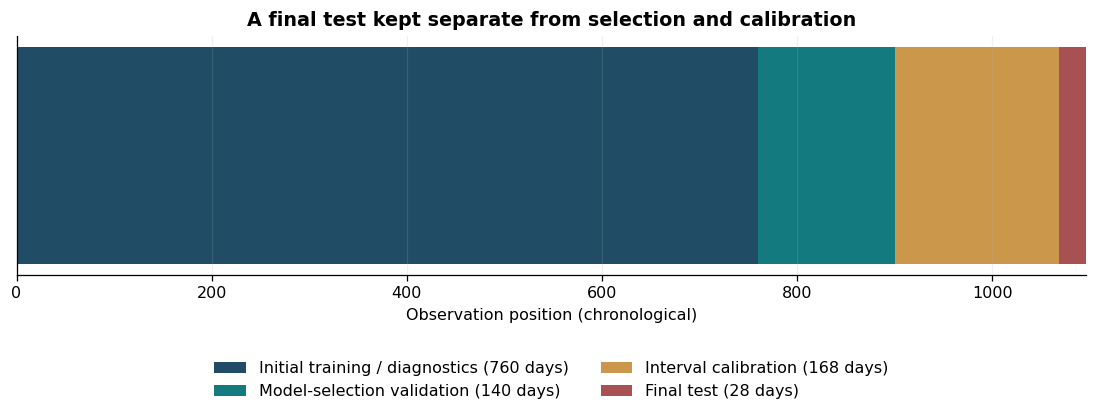

In [4]:
test_start = len(y) - HORIZON
calibration_start = test_start - N_CALIBRATION_FOLDS * HORIZON
selection_start = calibration_start - N_SELECTION_FOLDS * HORIZON
assert selection_start >= 2 * 365, "Need two initial years for this study design."
initial = y.iloc[:selection_start].copy()

def expanding_window_splits(n, n_folds, horizon, min_train_size):
    if n < min_train_size + n_folds * horizon:
        raise ValueError("Insufficient history for the requested folds.")
    return [(slice(0, n-(n_folds-i)*horizon),
             slice(n-(n_folds-i)*horizon, n-(n_folds-i-1)*horizon))
            for i in range(n_folds)]

selection_splits = expanding_window_splits(calibration_start, N_SELECTION_FOLDS, HORIZON, 730)
calibration_splits = expanding_window_splits(test_start, N_CALIBRATION_FOLDS, HORIZON, calibration_start)
stage_windows = [("Initial training / diagnostics", 0, selection_start),
                 ("Model-selection validation", selection_start, calibration_start),
                 ("Interval calibration", calibration_start, test_start),
                 ("Final test", test_start, len(y))]
partition_table = pd.DataFrame([{
    "stage": name, "first_day": str(y.index[a].date()),
    "last_day": str(y.index[b-1].date()), "n_days": b-a
} for name, a, b in stage_windows])
display(partition_table)
partition_table.to_csv(OUT / "partitions.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 2.7))
stage_colors = ["#214c66", "#137b80", "#cb984b", "#a75153"]
for i, (name, a, b) in enumerate(stage_windows):
    ax.barh(0, b-a, left=a, height=0.55, color=stage_colors[i], label=f"{name} ({b-a} days)")
ax.set(xlim=(0, len(y)), xlabel="Observation position (chronological)", yticks=[],
       title="A final test kept separate from selection and calibration")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
save_figure(fig, "01_chronology.png")
print(f"Diagnostics will use only the first {len(initial)} observations.")

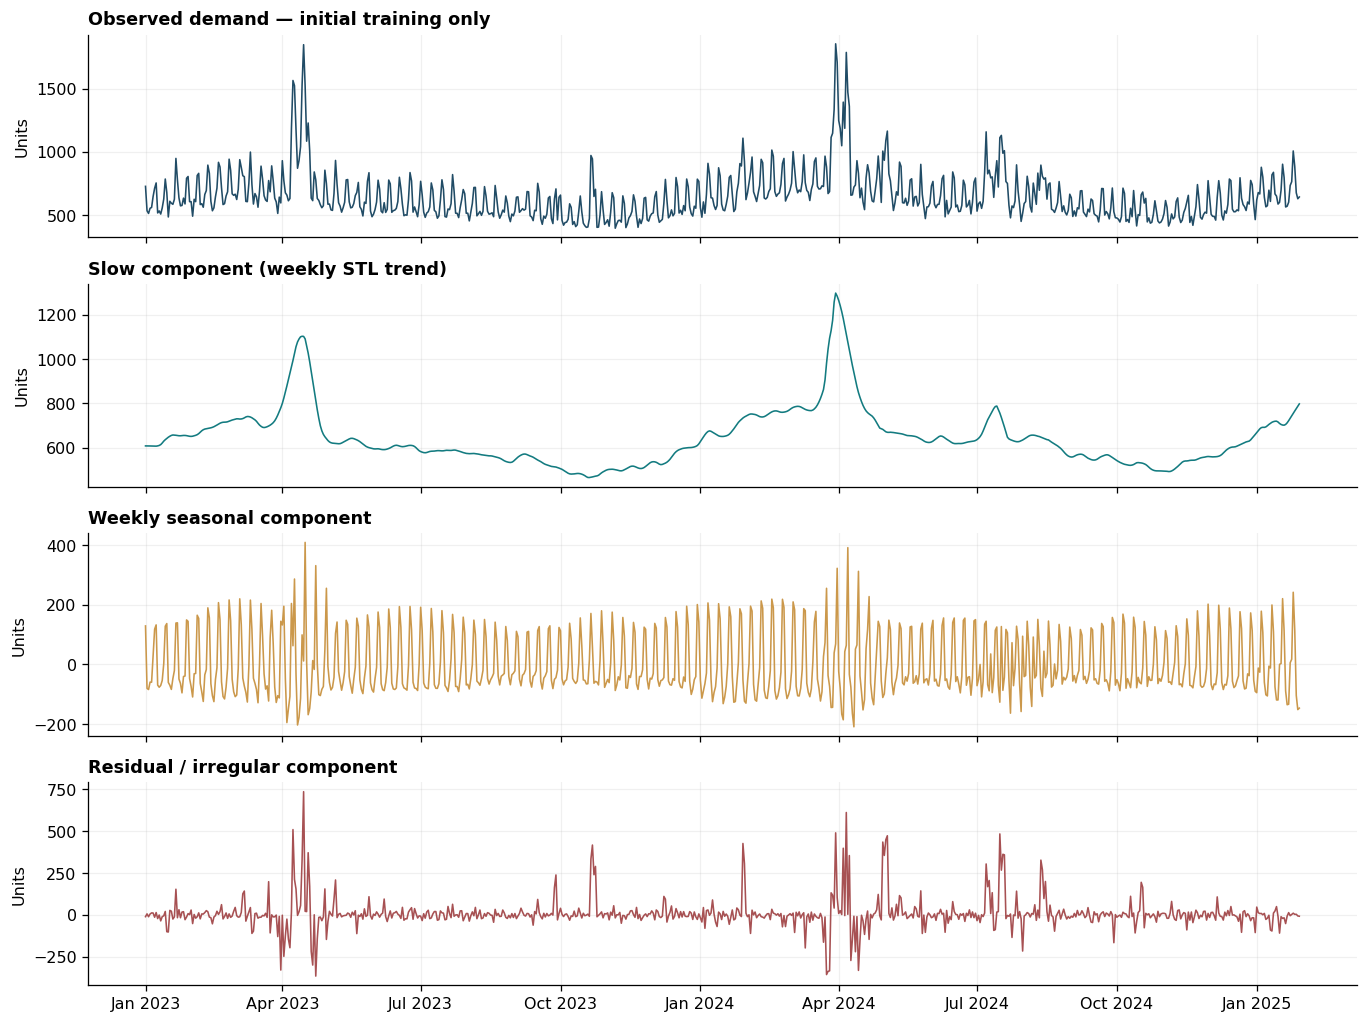

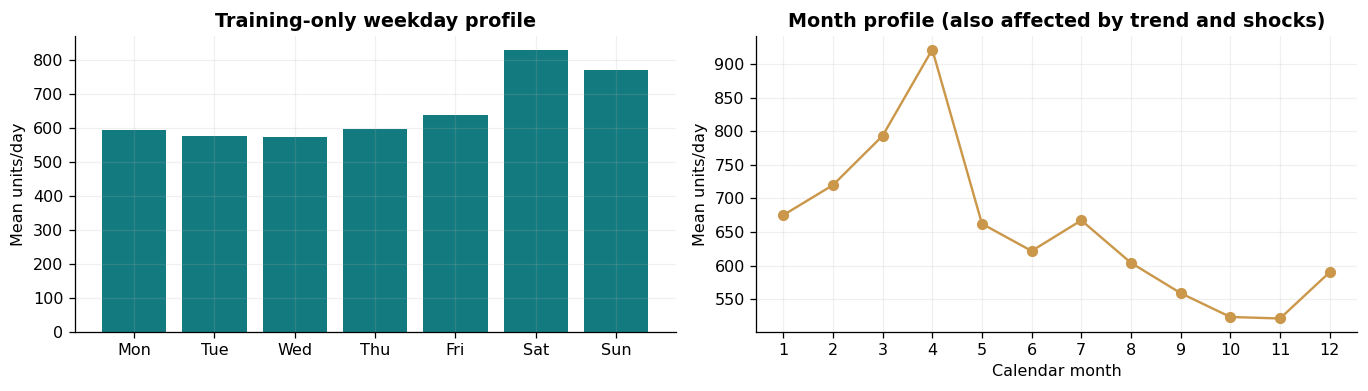

,n,minimum,maximum,mean,seasonal_strength_weekly,acf_lag_7,acf_lag_28,acf_lag_365
0,760,397.0,1855.0,655.196,0.501,0.661,0.468,0.191


In [5]:
stl = STL(initial, period=PERIOD, robust=True).fit()
denom = np.var(stl.seasonal + stl.resid)
seasonal_strength = max(0.0, 1.0 - np.var(stl.resid) / denom) if denom > 0 else np.nan
r = acf(initial, nlags=365, fft=True)
eda_summary = {
    "n": len(initial), "minimum": float(initial.min()), "maximum": float(initial.max()),
    "mean": float(initial.mean()), "seasonal_strength_weekly": float(seasonal_strength),
    "acf_lag_7": float(r[7]), "acf_lag_28": float(r[28]), "acf_lag_365": float(r[365]),
}
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, values, title, color in zip(axes,
        [initial, stl.trend, stl.seasonal, stl.resid],
        ["Observed demand — initial training only", "Slow component (weekly STL trend)",
         "Weekly seasonal component", "Residual / irregular component"],
        ["#214c66", "#137b80", "#cb984b", "#a75153"]):
    ax.plot(initial.index, values, color=color, linewidth=1)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel("Units")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.tight_layout()
save_figure(fig, "02_stl_diagnostics.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
dow = initial.groupby(initial.index.dayofweek).mean().reindex(range(7))
axes[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow, color="#137b80")
axes[0].set(title="Training-only weekday profile", ylabel="Mean units/day")
monthly = initial.groupby(initial.index.month).mean().reindex(range(1, 13))
axes[1].plot(monthly.index, monthly, color="#cb984b", marker="o")
axes[1].set(title="Month profile (also affected by trend and shocks)",
            xlabel="Calendar month", xticks=range(1, 13), ylabel="Mean units/day")
fig.tight_layout()
save_figure(fig, "03_calendar_profiles.png")
display(pd.DataFrame([eda_summary]).round(3))

**Interpretation of the training-only decomposition.** Demand ranges from
397 to 1855 units over the initial 760 days, with a
mean of 655.20. The weekly profile has a clear lift near the end of the
week, and the robust STL seasonal-strength statistic is
**0.501**. Its residual component retains large
positive spikes: a smooth weekly forecast cannot explain every promotion-like event.
These spikes are retained rather than cleaned away.

Autocorrelation is **0.661 at lag 7** and
**0.468 at lag 28**, supporting explicit weekly structure. The
lag-365 correlation is weaker (0.191); annual repetition is not
an exact copy of a prior day because weekday alignment, trend, and moving shocks
also change. The month profile provides context but mixes trend and shocks with
calendar effects. Weekly STL's slow component absorbs longer movements; this is
not a separate estimate of yearly seasonality.

### 1.3 ACF/PACF and ADF: test, interpret, and difference when warranted

ADF's null is a unit root. We use an intercept and linear trend on the original
series and compare its p-value with 0.05. Failure to reject triggers a first
difference for the diagnostic view; a weekly difference is also checked.
Rejection is not proof that all seasonal patterns or regime changes have vanished.
ACF/PACF are read alongside STL rather than mechanically converting one spike
into an ARIMA order. The models below are level-based Holt-Winters and LightGBM,
so no unmotivated ARIMA differencing order is introduced.

Chosen diagnostic view: First difference


<ipython-input-6-29d6f8a56fc8>:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a = adfuller(np.asarray(values), regression=regression, autolag="AIC")
<ipython-input-6-29d6f8a56fc8>:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a = adfuller(np.asarray(values), regression=regression, autolag="AIC")
<ipython-input-6-29d6f8a56fc8>:2: FutureWarning: adfuller currently retu

,series,ADF_statistic,p_value,selected_lags,n_obs,critical_5pct,deterministic_terms,reject_unit_root_5pct
0,Original,-2.70568,0.23373,20,739,-3.41645,ct,False
1,First difference,-8.74700,0.00000,20,738,-2.86546,c,True
2,Seven-day difference,-8.63687,0.00000,20,732,-2.86550,c,True


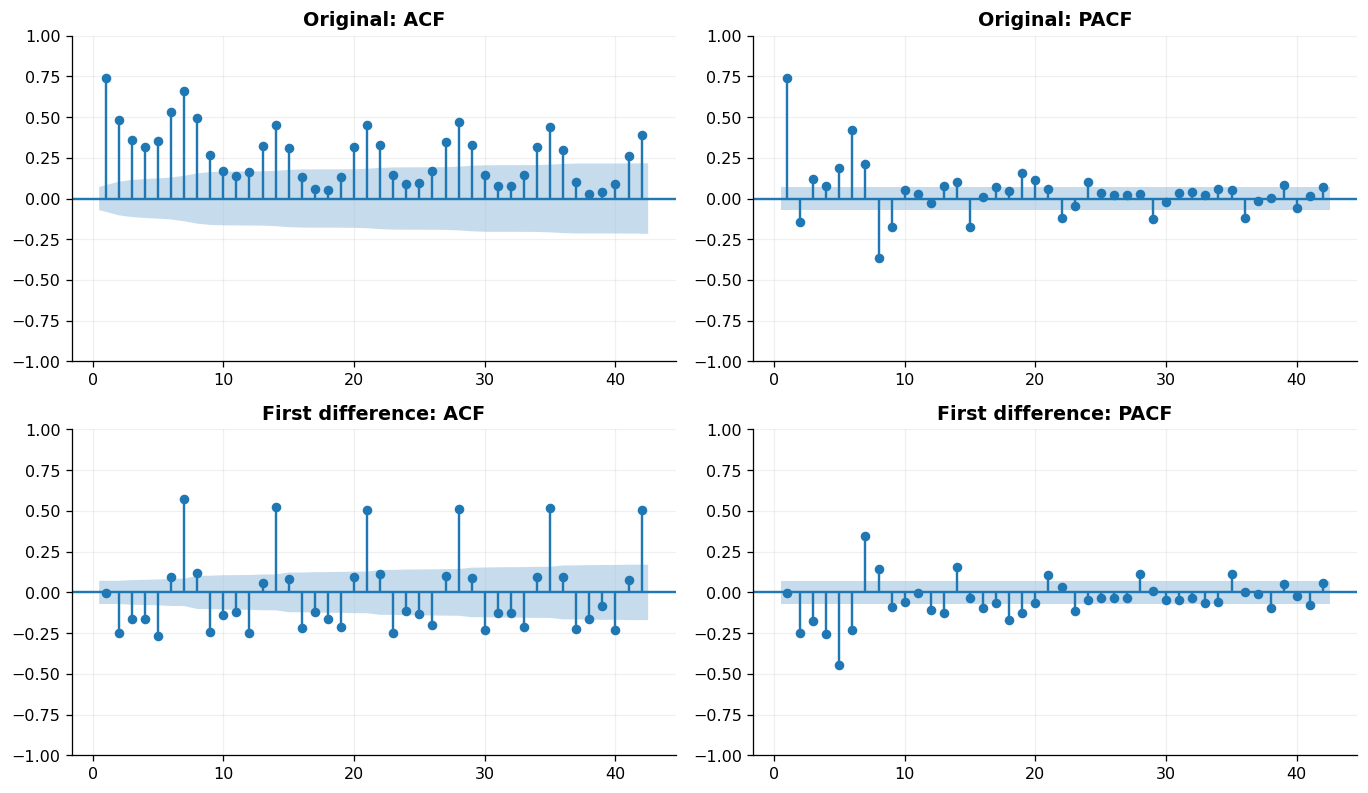

In [6]:
def adf_row(values, label, regression="c"):
    a = adfuller(np.asarray(values), regression=regression, autolag="AIC")
    return {"series": label, "ADF_statistic": a[0], "p_value": a[1],
            "selected_lags": a[2], "n_obs": a[3], "critical_5pct": a[4]["5%"],
            "deterministic_terms": regression, "reject_unit_root_5pct": bool(a[1] < 0.05)}

adf_table = pd.DataFrame([
    adf_row(initial, "Original", "ct"),
    adf_row(initial.diff().dropna(), "First difference", "c"),
    adf_row(initial.diff(PERIOD).dropna(), "Seven-day difference", "c"),
])
display(adf_table.round(5))
needs_difference = not bool(adf_table.loc[0, "reject_unit_root_5pct"])
diagnostic_series = initial.diff().dropna() if needs_difference else initial
diagnostic_label = "First difference" if needs_difference else "Original (ADF rejects a unit root)"
print("Chosen diagnostic view:", diagnostic_label)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(initial, lags=42, zero=False, ax=axes[0, 0], title="Original: ACF")
plot_pacf(initial, lags=42, zero=False, method="ywm", ax=axes[0, 1], title="Original: PACF")
plot_acf(diagnostic_series, lags=42, zero=False, ax=axes[1, 0], title=f"{diagnostic_label}: ACF")
plot_pacf(diagnostic_series, lags=42, zero=False, method="ywm", ax=axes[1, 1], title=f"{diagnostic_label}: PACF")
fig.tight_layout()
save_figure(fig, "04_acf_pacf.png")
adf_table.to_csv(OUT / "adf_tests.csv", index=False)

**Stationarity decision.** The original-series ADF p-value is
**0.2337**, so at 5% we fail to reject the unit-root null even
with a deterministic linear trend included. This is evidence to investigate
differencing, not proof of a unit root. A first difference is therefore actually
applied in the lower ACF/PACF plots. Its ADF p-value is
**2.90e-14**, while the seven-day difference gives
**5.56e-14**; both reject the unit-root null.

**ACF/PACF reading.** The original ACF decays slowly and rises again around
7, 14, 21, and 28 days. The original PACF has a strong first lag plus structure
around the weekly lags rather than a clean single-order cutoff. After first
differencing, pronounced weekly ACF spikes remain: removing slow movement does
not remove weekly seasonality. That supports a seasonal component and weekly
lag features, not treating the differenced series as white noise.

Holt-Winters is intentionally fitted to levels because it explicitly represents
level, trend, and weekly effects. LightGBM also models levels using lag and calendar
features. We do not incorrectly require these models to consume differenced values
solely because an ARIMA model might need an integration term.

## 2. Classical model and a baseline

**Seasonal Naive:** Repeat the last seven observed days. This is the operational
benchmark every fitted model must justify improving upon.

**Holt-Winters:** Fit an additive level/trend with **damped trend** and
**multiplicative weekly seasonality** (`seasonal_periods=7`). Positive counts make
multiplicative seasonality valid, and relative weekly effects can grow with the
level. Damping avoids indefinite linear extrapolation. Coefficients and initial
states are estimated only within each training prefix; the form and period are
fixed before validation. We divide the training target by 1,000 for numerical
conditioning and restore forecasts to units; this changes no information boundary.

This model has one explicit seasonal cycle; it cannot independently capture a
365-day cycle or an unannounced promotion. That limitation must be checked in the
residuals and in actual forward forecasts.

Fit warnings: none
Ljung-Box uses model_df=0; p-values are an exploratory ETS residual screen.


,smoothing_level,smoothing_trend,smoothing_seasonal,damping_trend
0,0.73189,0.0,0.0,0.8


,lb_stat,lb_pvalue
lag,,
14,46.872465,0.000020
28,60.313624,0.000371


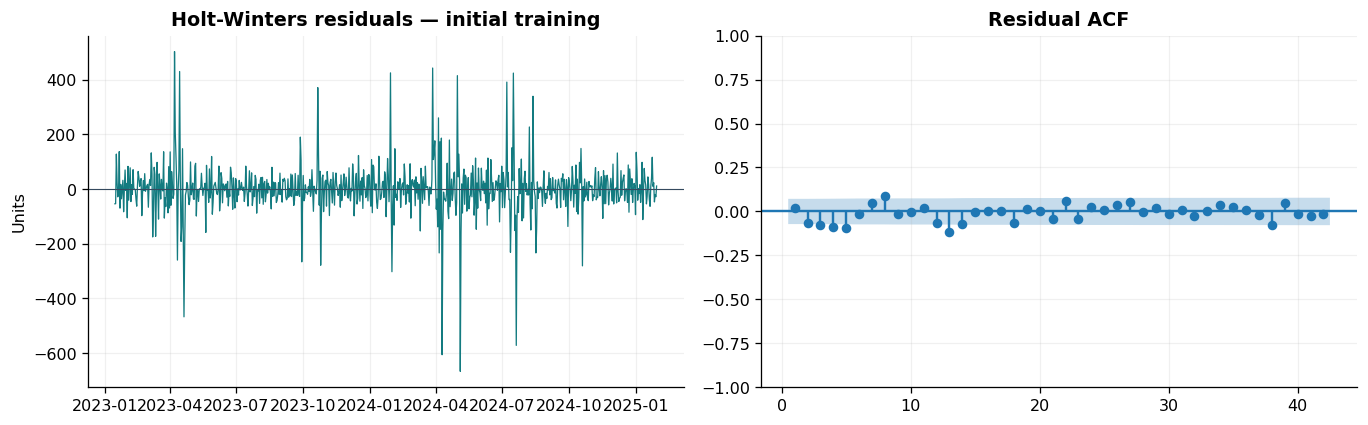

In [7]:
def fit_holt_winters(history):
    if np.any(np.asarray(history) <= 0):
        raise ValueError("Multiplicative Holt-Winters requires strictly positive history.")
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always")
        fit = ExponentialSmoothing(
            history / 1000.0, trend="add", damped_trend=True,
            seasonal="mul", seasonal_periods=PERIOD,
            initialization_method="estimated",
        ).fit(optimized=True, use_brute=False)
    success = bool(fit.mle_retvals.get("success", True))
    if not success:
        raise RuntimeError(f"Holt-Winters optimizer failed: {fit.mle_retvals}")
    return fit, [str(w.message) for w in captured]

initial_hw, initial_hw_warnings = fit_holt_winters(initial)
residuals = pd.Series(np.asarray(initial_hw.resid) * 1000.0, index=initial.index).iloc[2*PERIOD:]
lb = acorr_ljungbox(residuals, lags=[14, 28], model_df=0, return_df=True)
lb.index.name = "lag"
hw_parameters = {k: float(initial_hw.params[k]) for k in
                 ["smoothing_level", "smoothing_trend", "smoothing_seasonal", "damping_trend"]}
display(pd.DataFrame([hw_parameters]).round(5))
display(lb.round(6))
print("Fit warnings:", initial_hw_warnings or "none")
print("Ljung-Box uses model_df=0; p-values are an exploratory ETS residual screen.")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(residuals.index, residuals, color="#137b80", linewidth=0.8)
axes[0].axhline(0, color="#34495e", linewidth=0.7)
axes[0].set(title="Holt-Winters residuals — initial training", ylabel="Units")
plot_acf(residuals, lags=42, zero=False, ax=axes[1], title="Residual ACF")
fig.tight_layout()
save_figure(fig, "05_classical_residuals.png")
lb.to_csv(OUT / "holt_winters_ljung_box.csv")

**Residual finding.** Ljung-Box p-values are **2.02e-05 at lag 14**
and **3.71e-04 at lag 28**. Both are below 0.05, so the residuals
retain temporal structure in this exploratory screen. The forecast is not presented
as fully adequate or as having independent noise simply because it fitted successfully.
Unmodelled long-cycle movement and irregular demand events are plausible explanations,
not uniquely identified causes. Forward error is the deciding evidence.

The initial fit puts trend and seasonal smoothing at zero, while level smoothing is
0.732 and damping is
0.800. Thus the weekly pattern is largely
carried by the fitted initial seasonal states, while updates mainly adjust level.
Boundary estimates and residual correlation limit a strong structural interpretation
of this fit. These are the parameters of this initial diagnostic fit, not a claim
that every later fold has identical coefficients.

## 3. LightGBM and causal temporal features

| Feature group | Variables | Available at forecast time? |
|---|---|---|
| Lags | 1, 2, 3, 7, 14, 21, 28 days | Observed history, then earlier recursive predictions |
| Rolling statistics | Mean/std over 7, 14, 28, 56 days; min/max over 28 days | Training uses `shift(1)` before rolling |
| Calendar | Weekday, month, day of year, week of year | Known from the target date |
| Cyclic terms | Weekday sin/cos; two annual Fourier pairs | Deterministic from the target date |
| Time index | Days since the dataset start | Known; trees cannot extrapolate trends freely |

The model uses 350 trees, learning rate 0.035, 15 leaves, a minimum of 30 samples per
leaf, L2 regularization of 2.0, and a fixed seed. These settings limit complexity for
roughly 700 initial supervised rows. They are fixed before validation, with no hidden
hyperparameter search or early-stopping split.

For a 28-day forecast, tomorrow's predicted demand becomes part of the history used
to forecast the next day. **The 28 future actual values are never passed into this
function.** We include two executable leakage checks below.

كل lag أو rolling يعتمد على الماضي فقط. بعد أول يوم في فترة التنبؤ، نستخدم توقعاتنا
السابقة بدل القيم الفعلية التي لم تكن معروفة وقت إصدار التوقع.

In [8]:
LAGS = (1, 2, 3, 7, 14, 21, 28)
WINDOWS = (7, 14, 28, 56)
LGBM_PARAMS = dict(n_estimators=350, learning_rate=0.035, num_leaves=15,
                   min_child_samples=30, reg_lambda=2.0, random_state=SEED,
                   n_jobs=2, verbosity=-1, deterministic=True, force_col_wise=True)

def calendar_features(index):
    index = pd.DatetimeIndex(index)
    f = pd.DataFrame(index=index)
    f["day_of_week"] = index.dayofweek.astype(float)
    f["month"] = index.month.astype(float)
    f["day_of_year"] = index.dayofyear.astype(float)
    f["week_of_year"] = index.isocalendar().week.to_numpy(dtype=float)
    f["trend_days"] = (index - EPOCH).days.astype(float)
    f["dow_sin"] = np.sin(2 * np.pi * index.dayofweek / 7)
    f["dow_cos"] = np.cos(2 * np.pi * index.dayofweek / 7)
    for k in (1, 2):
        f[f"year_sin_{k}"] = np.sin(2 * np.pi * k * index.dayofyear / 365.25)
        f[f"year_cos_{k}"] = np.cos(2 * np.pi * k * index.dayofyear / 365.25)
    return f

def make_features(series):
    f = calendar_features(series.index)
    for lag in LAGS:
        f[f"lag_{lag}"] = series.shift(lag)
    past = series.shift(1)
    for window in WINDOWS:
        f[f"rolling_mean_{window}"] = past.rolling(window).mean()
        f[f"rolling_std_{window}"] = past.rolling(window).std(ddof=0)
    f["rolling_min_28"] = past.rolling(28).min()
    f["rolling_max_28"] = past.rolling(28).max()
    return f

def next_feature_row(history_values, target_date, columns):
    values = np.asarray(history_values, dtype=float)
    if len(values) < max(WINDOWS):
        raise ValueError("Not enough history for rolling features.")
    f = calendar_features(pd.DatetimeIndex([target_date]))
    for lag in LAGS:
        f[f"lag_{lag}"] = values[-lag]
    for window in WINDOWS:
        f[f"rolling_mean_{window}"] = values[-window:].mean()
        f[f"rolling_std_{window}"] = values[-window:].std(ddof=0)
    f["rolling_min_28"] = values[-28:].min()
    f["rolling_max_28"] = values[-28:].max()
    return f.reindex(columns=columns)

def fit_model(name, history):
    history = history.copy()
    start = time.perf_counter()
    result = {"name": name, "history": history, "fit_warnings": []}
    if name == "Holt-Winters":
        result["model"], result["fit_warnings"] = fit_holt_winters(history)
    elif name == "LightGBM":
        X = make_features(history).dropna()
        result["columns"] = list(X.columns)
        result["model"] = LGBMRegressor(**LGBM_PARAMS).fit(X, history.loc[X.index])
        result["supervised_rows"] = len(X)
    elif name != "Seasonal Naive":
        raise ValueError(name)
    result["fit_seconds"] = time.perf_counter() - start
    return result

def predict_model(fitted, horizon):
    start = time.perf_counter()
    history = fitted["history"]
    dates = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    trace = []
    if fitted["name"] == "Seasonal Naive":
        pred = np.resize(history.iloc[-PERIOD:].to_numpy(), horizon)
    elif fitted["name"] == "Holt-Winters":
        pred = np.asarray(fitted["model"].forecast(horizon)) * 1000.0
    else:
        values = list(history.to_numpy(dtype=float))
        predictions = []
        for step, date in enumerate(dates, 1):
            X = next_feature_row(values, date, fitted["columns"])
            point = max(0.0, float(fitted["model"].predict(X)[0]))
            trace.append({"horizon": step, "date": date, "lag_1": float(X["lag_1"].iloc[0]),
                          "prediction": point,
                          "last_observed_date": history.index[-1],
                          "previous_input_type": "observed" if step == 1 else "predicted"})
            predictions.append(point)
            values.append(point)  # Crucially: append a prediction, never a future actual.
        pred = np.asarray(predictions)
    pred = np.maximum(0.0, np.asarray(pred, dtype=float))
    assert pred.shape == (horizon,) and np.isfinite(pred).all()
    return pd.Series(pred, index=dates), time.perf_counter() - start, pd.DataFrame(trace)

# Check 1: replacing the target day and everything later cannot change that day's features.
cut = len(initial) - HORIZON
original_features = make_features(initial)
corrupted = initial.copy()
corrupted.iloc[cut:] += 1_000_000
corrupted_features = make_features(corrupted)
np.testing.assert_allclose(original_features.iloc[cut], corrupted_features.iloc[cut], rtol=1e-9, atol=1e-6)

# The vectorized training path and one-step inference path must agree.
one_step = next_feature_row(initial.iloc[:cut].to_numpy(), initial.index[cut], original_features.columns)
np.testing.assert_allclose(one_step.iloc[0], original_features.iloc[cut], rtol=1e-9, atol=1e-6)

# Check 2: recursive step h+1 must take step h's prediction as lag 1.
initial_ml = fit_model("LightGBM", initial)
_, _, recursion_trace = predict_model(initial_ml, HORIZON)
np.testing.assert_allclose(recursion_trace["lag_1"].iloc[1:], recursion_trace["prediction"].iloc[:-1])
assert recursion_trace["last_observed_date"].eq(initial.index[-1]).all()
display(original_features.dropna().head(3).round(2))
display(recursion_trace.head(8))
print(f"Leakage checks passed. {initial_ml['supervised_rows']} training rows, {len(initial_ml['columns'])} features.")
recursion_trace.to_csv(OUT / "recursive_feature_audit.csv", index=False)

Leakage checks passed. 704 training rows, 28 features.


,day_of_week,month,day_of_year,week_of_year,trend_days,dow_sin,dow_cos,year_sin_1,year_cos_1,year_sin_2,year_cos_2,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_mean_56,rolling_std_56,rolling_min_28,rolling_max_28
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-02-26,6.0,2.0,57.0,8.0,56.0,-0.78,0.62,0.83,0.56,0.92,-0.38,943.0,685.0,652.0,881.0,832.0,831.0,806.0,721.86,129.07,704.57,131.87,687.39,125.24,659.00,119.54,492.0,943.0
2023-02-27,0.0,2.0,58.0,9.0,57.0,0.00,1.00,0.84,0.54,0.91,-0.41,855.0,943.0,685.0,717.0,610.0,584.0,607.0,718.14,124.74,706.21,133.58,689.14,127.22,661.27,122.01,492.0,943.0
2023-02-28,1.0,2.0,59.0,9.0,58.0,0.78,0.62,0.85,0.53,0.90,-0.44,669.0,855.0,943.0,584.0,535.0,591.0,607.0,711.29,125.93,710.43,131.39,691.36,126.30,663.66,120.82,492.0,943.0


,horizon,date,lag_1,prediction,last_observed_date,previous_input_type
0,1,2025-01-30,644.000000,761.185525,2025-01-29,observed
1,2,2025-01-31,761.185525,747.697362,2025-01-29,predicted
2,3,2025-02-01,747.697362,912.666855,2025-01-29,predicted
3,4,2025-02-02,912.666855,892.324871,2025-01-29,predicted
4,5,2025-02-03,892.324871,767.067207,2025-01-29,predicted
5,6,2025-02-04,767.067207,704.747731,2025-01-29,predicted
6,7,2025-02-05,704.747731,715.500867,2025-01-29,predicted
7,8,2025-02-06,715.500867,745.617453,2025-01-29,predicted


## 4. Five-fold walk-forward backtesting

This self-contained harness implements the course harness's expanding-prefix
contract, while keeping timestamps and runtime measurements. Each test window
contains exactly 28 dates and begins one day after its training prefix ends.
No model is warm-started with parameters fitted to a later window.

### 4.1 Metric definitions

- **MAE:** mean absolute forecast error, in units/day.
- **RMSE:** square root of mean squared error; large misses cost more.
- **WAPE (%):** total absolute error / total actual volume × 100; the primary score.
- **MASE (s=7):** MAE divided by mean absolute seven-day differences in that fold's
  **training** history. Below one means below that training seasonal-naive scale;
  it does not by itself prove improvement over the held-out baseline.

The series has no zero days, but WAPE is still a readable, scale-free business
metric and tolerates isolated zero days. We avoid MAPE's per-day division by small
values. WAPE is undefined if an entire evaluation window has zero total demand;
the function returns `NaN` in that case rather than a misleading percentage.

In [9]:
def mae(actual, prediction):
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(prediction))))

def rmse(actual, prediction):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(prediction)) ** 2)))

def wape(actual, prediction):
    denominator = float(np.sum(np.abs(actual)))
    return 100.0 * float(np.sum(np.abs(np.asarray(actual)-np.asarray(prediction)))) / denominator if denominator > 0 else np.nan

def seasonal_scale(training, period=PERIOD):
    a = np.asarray(training, dtype=float)
    if len(a) <= period:
        raise ValueError("Training history is too short for MASE.")
    return float(np.mean(np.abs(a[period:] - a[:-period])))

def mase(actual, prediction, training, period=PERIOD):
    scale = seasonal_scale(training, period)
    return mae(actual, prediction) / scale if scale > 0 else np.nan

def coverage(actual, lower, upper):
    actual, lower, upper = map(np.asarray, (actual, lower, upper))
    return float(np.mean((actual >= lower) & (actual <= upper)))

def interval_width(lower, upper):
    return float(np.mean(np.asarray(upper) - np.asarray(lower)))

def metric_row(actual, prediction, training):
    return {"MAE": mae(actual, prediction), "RMSE": rmse(actual, prediction),
            "WAPE_pct": wape(actual, prediction), "MASE_s7": mase(actual, prediction, training)}

def run_backtest(series, splits, stage):
    rows, predictions, boundaries = [], [], []
    for fold, (train_slice, test_slice) in enumerate(splits, 1):
        train, truth = series.iloc[train_slice].copy(), series.iloc[test_slice].copy()
        assert train_slice.stop == test_slice.start
        assert len(truth) == HORIZON and train.index.max() < truth.index.min()
        assert truth.index.min() == train.index.max() + pd.Timedelta(days=1)
        boundaries.append({"stage": stage, "fold": fold, "train_start": train.index[0],
                           "train_end": train.index[-1], "test_start": truth.index[0],
                           "test_end": truth.index[-1], "train_n": len(train), "test_n": len(truth)})
        for name in MODELS:
            fitted = fit_model(name, train)
            pred, predict_seconds, _ = predict_model(fitted, len(truth))
            assert pred.index.equals(truth.index)
            rows.append({"stage": stage, "fold": fold, "model": name, "train_n": len(train),
                         **metric_row(truth, pred, train), "fit_seconds": fitted["fit_seconds"],
                         "predict_seconds": predict_seconds, "warning_count": len(fitted["fit_warnings"])})
            predictions.append(pd.DataFrame({
                "stage": stage, "fold": fold, "model": name, "origin": train.index[-1],
                "date": truth.index, "horizon": np.arange(1, len(truth)+1),
                "actual": truth.to_numpy(), "prediction": pred.to_numpy(),
                "seasonal_scale": seasonal_scale(train),
            }))
        print(f"{stage}: fold {fold}/{len(splits)} | trained through {train.index[-1].date()} | "
              f"forecast {truth.index[0].date()} to {truth.index[-1].date()}")
    return pd.DataFrame(rows), pd.concat(predictions, ignore_index=True), pd.DataFrame(boundaries)

selection_scores, selection_predictions, selection_boundaries = run_backtest(
    y.iloc[:calibration_start], selection_splits, "selection")
assert len(selection_scores) == N_SELECTION_FOLDS * len(MODELS)
assert selection_predictions.groupby(["model", "fold"]).size().eq(HORIZON).all()
display(selection_boundaries)
display(selection_scores.round(4))
selection_boundaries.to_csv(OUT / "selection_fold_boundaries.csv", index=False)
selection_scores.to_csv(OUT / "selection_fold_metrics.csv", index=False)
selection_predictions.to_csv(OUT / "selection_predictions.csv", index=False)

selection: fold 1/5 | trained through 2025-01-29 | forecast 2025-01-30 to 2025-02-26
selection: fold 2/5 | trained through 2025-02-26 | forecast 2025-02-27 to 2025-03-26
selection: fold 3/5 | trained through 2025-03-26 | forecast 2025-03-27 to 2025-04-23
selection: fold 4/5 | trained through 2025-04-23 | forecast 2025-04-24 to 2025-05-21
selection: fold 5/5 | trained through 2025-05-21 | forecast 2025-05-22 to 2025-06-18


,stage,fold,train_start,train_end,test_start,test_end,train_n,test_n
0,selection,1,2023-01-01,2025-01-29,2025-01-30,2025-02-26,760,28
1,selection,2,2023-01-01,2025-02-26,2025-02-27,2025-03-26,788,28
2,selection,3,2023-01-01,2025-03-26,2025-03-27,2025-04-23,816,28
3,selection,4,2023-01-01,2025-04-23,2025-04-24,2025-05-21,844,28
4,selection,5,2023-01-01,2025-05-21,2025-05-22,2025-06-18,872,28


,stage,fold,model,train_n,MAE,RMSE,WAPE_pct,MASE_s7,fit_seconds,predict_seconds,warning_count
0,selection,1,Seasonal Naive,760,83.7500,140.6750,10.1091,0.9731,0.0000,0.0005,0
1,selection,1,Holt-Winters,760,97.4677,154.8998,11.7649,1.1325,0.0306,0.0092,0
2,selection,1,LightGBM,760,87.9471,147.3440,10.6157,1.0219,0.2738,0.2276,0
3,selection,2,Seasonal Naive,788,337.2500,515.1635,30.4367,3.8747,0.0000,0.0004,0
4,selection,2,Holt-Winters,788,339.1334,531.9458,30.6067,3.8964,0.0336,0.0092,0
5,selection,2,LightGBM,788,333.8082,501.2469,30.1261,3.8352,0.2948,0.2436,0
6,selection,3,Seasonal Naive,816,584.8214,613.5280,72.9561,6.1246,0.0000,0.0005,0
7,selection,3,Holt-Winters,816,652.2536,678.4385,81.3682,6.8308,0.0481,0.0095,0
8,selection,3,LightGBM,816,592.8093,621.9988,73.9526,6.2083,0.3359,0.2776,0
9,selection,4,Seasonal Naive,844,38.1786,50.7603,5.2756,0.3881,0.0000,0.0005,0


## 5. Accuracy reporting and frozen model choice

Pooled MAE/RMSE/WAPE are computed from all 140 out-of-sample predictions per model.
MASE is reported as the mean of the five fold-specific scores. These are not training
fit metrics. The per-fold table and plots reveal variability hidden by an average.

**Prespecified choice rule:** minimize selection WAPE. If multiple models lie
within **2% relative** of the minimum WAPE, prefer the simpler eligible model
(Seasonal Naive → Holt-Winters → LightGBM). This balances accuracy with maintenance
and compute. The rule and choice are frozen before examining calibration or final-test outcomes.

Frozen selection: Seasonal Naive
Models within the complexity tolerance: ['Seasonal Naive']


,model,MAE,RMSE,WAPE_pct,mean_fold_MASE_s7,mean_fit_seconds,mean_predict_seconds,worst_fold_WAPE_pct,WAPE_improvement_vs_baseline_pct
0,Seasonal Naive,216.1286,365.0682,26.1304,2.3480,0.0000,0.0005,72.9561,0.0000
1,LightGBM,231.8382,367.5375,28.0298,2.5104,0.2847,0.2504,73.9526,-7.2686
2,Holt-Winters,232.4743,392.9272,28.1067,2.5228,0.0420,0.0112,81.3682,-7.5630


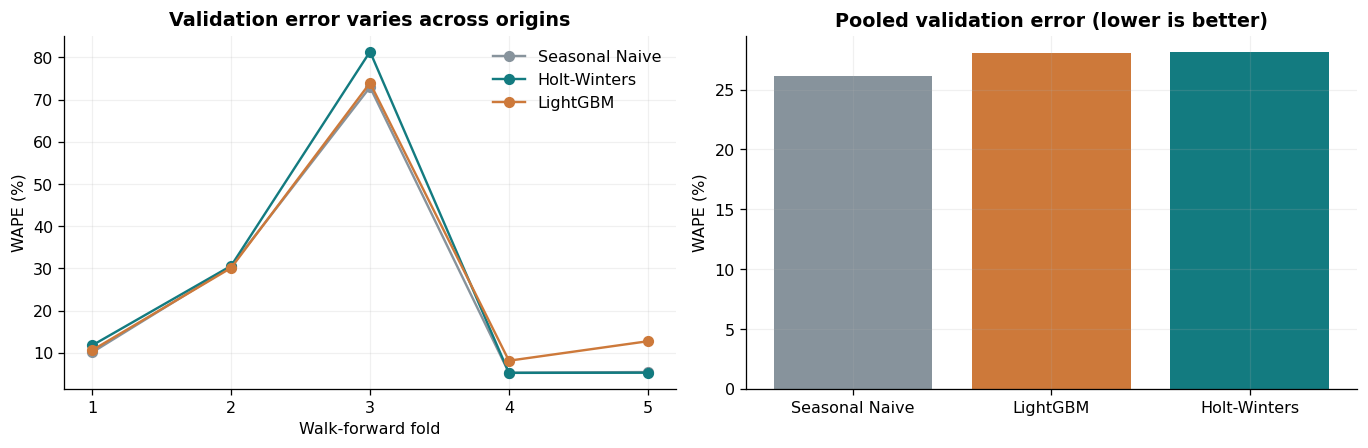

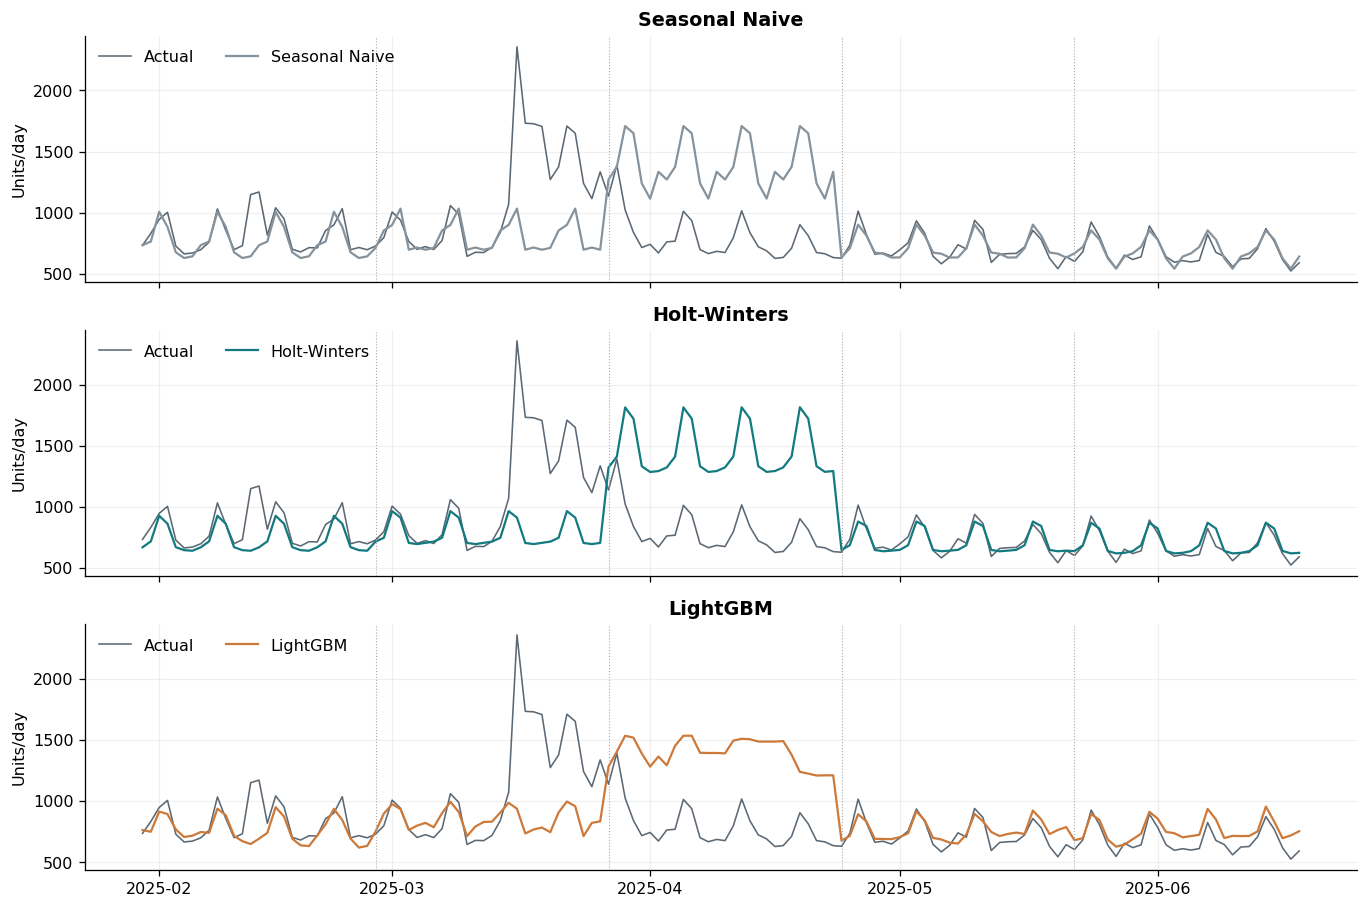

In [10]:
summary_rows = []
for name in MODELS:
    p = selection_predictions.query("model == @name")
    f = selection_scores.query("model == @name")
    summary_rows.append({
        "model": name, "MAE": mae(p.actual, p.prediction), "RMSE": rmse(p.actual, p.prediction),
        "WAPE_pct": wape(p.actual, p.prediction), "mean_fold_MASE_s7": float(f.MASE_s7.mean()),
        "mean_fit_seconds": float(f.fit_seconds.mean()),
        "mean_predict_seconds": float(f.predict_seconds.mean()),
        "worst_fold_WAPE_pct": float(f.WAPE_pct.max()),
    })
selection_summary = pd.DataFrame(summary_rows).sort_values("WAPE_pct").reset_index(drop=True)
baseline_wape = float(selection_summary.set_index("model").loc["Seasonal Naive", "WAPE_pct"])
selection_summary["WAPE_improvement_vs_baseline_pct"] = 100 * (1 - selection_summary.WAPE_pct / baseline_wape)
best_wape = float(selection_summary.WAPE_pct.min())
eligible = set(selection_summary.loc[selection_summary.WAPE_pct <= best_wape*(1+COMPLEXITY_TOLERANCE), "model"])
selected_model = next(name for name in MODELS if name in eligible)
display(selection_summary.round(4))
print("Frozen selection:", selected_model)
print("Models within the complexity tolerance:", sorted(eligible))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name in MODELS:
    f = selection_scores.query("model == @name")
    axes[0].plot(f.fold, f.WAPE_pct, marker="o", label=name, color=COLORS[name])
axes[0].set(title="Validation error varies across origins", xlabel="Walk-forward fold", ylabel="WAPE (%)", xticks=range(1,6))
axes[0].legend(frameon=False)
axes[1].bar(selection_summary.model, selection_summary.WAPE_pct,
            color=[COLORS[m] for m in selection_summary.model])
axes[1].set(title="Pooled validation error (lower is better)", ylabel="WAPE (%)")
fig.tight_layout()
save_figure(fig, "06_validation_comparison.png")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, name in zip(axes, MODELS):
    p = selection_predictions.query("model == @name")
    ax.plot(p.date, p.actual, color="#253746", alpha=0.75, linewidth=1, label="Actual")
    ax.plot(p.date, p.prediction, color=COLORS[name], linewidth=1.4, label=name)
    for origin in selection_boundaries.test_start.iloc[1:]:
        ax.axvline(origin, color="#aaaaaa", linestyle=":", linewidth=0.7)
    ax.set(title=name, ylabel="Units/day")
    ax.legend(loc="upper left", frameon=False, ncol=2)
fig.tight_layout()
save_figure(fig, "07_selection_predictions.png")
selection_summary.to_csv(OUT / "selection_summary.csv", index=False)

**What the five validation origins show.** Seasonal Naive is the lowest-error
pooled candidate at **26.13% WAPE**. LightGBM's
28.03% and Holt-Winters's
28.11% are outside the prespecified 2%
relative tie band. We therefore freeze **Seasonal Naive** before interval calibration.
The fitted models do not establish a validation improvement over the actual
held-out baseline. All mean fold MASE values also exceed one.

The average hides a substantial failure: **fold 3 (2025-03-27 to 2025-04-23)** has
WAPE of **72.96%** for Seasonal Naive,
81.37% for Holt-Winters, and
73.95% for LightGBM. Forecasts carried a high
recent demand level forward while actual demand fell. Later, calmer folds are much
easier for the weekly methods. This is a warning about sensitivity to the forecast
origin and unobserved shocks, not a reason to remove the difficult fold or report
only the most favourable period.

## 6. Prediction intervals: calibration, coverage, and width

### 6.1 Calibrate using six later forecast origins

Each calibration fold refits using only its own earlier history and produces a
28-day forecast. For each model, we pool absolute forecast errors within four
lead-time bands: days 1–7, 8–14, 15–21, and 22–28. Six origins × seven steps gives
**42 calibration errors per band**. Bands trade horizon specificity for sample size.

For `n` calibration errors, the 90% radius is the
`ceil((n+1)*0.90)`-th sorted absolute error. This finite-sample rank correction is
explicit; using the interpolated 90th percentile would implement a different rule.
Radii are made nondecreasing across bands using a cumulative maximum, a fixed
conservative design choice. Intervals are `prediction ± radius`, clipped below at zero.

**Scope of the uncertainty claim:** This is rolling-residual conformal calibration.
Dependent time-series errors and refitting across origins violate simple i.i.d.
split-conformal assumptions. We report **empirical** final-test coverage, not a
distribution-free guarantee. A nominal 90% pointwise interval is also not a 90%
simultaneous guarantee for all 28 days.

In [11]:
calibration_scores, calibration_predictions, calibration_boundaries = run_backtest(
    y.iloc[:test_start], calibration_splits, "calibration")
assert calibration_boundaries.test_end.max() < y.index[test_start]
calibration_predictions["absolute_error"] = np.abs(
    calibration_predictions.actual - calibration_predictions.prediction)
calibration_predictions["band"] = ((calibration_predictions.horizon - 1) // 7).astype(int)

def finite_sample_radius(scores, alpha):
    a = np.sort(np.asarray(scores, dtype=float))
    if not (0 < alpha < 1) or len(a) == 0 or not np.isfinite(a).all():
        raise ValueError("Invalid calibration scores or alpha.")
    rank = int(np.ceil((len(a)+1) * (1-alpha)))
    if rank > len(a):
        raise ValueError("Too few calibration observations for a finite radius at this level.")
    return float(a[rank-1]), rank

radius_records = []
for name in MODELS:
    prior_radius = 0.0
    for band in range(4):
        errors = calibration_predictions.query("model == @name and band == @band").absolute_error
        assert len(errors) == N_CALIBRATION_FOLDS * 7
        raw_radius, rank = finite_sample_radius(errors, ALPHA)
        used_radius = max(prior_radius, raw_radius)
        radius_records.append({"model": name, "band": band,
                               "horizon_days": f"{band*7+1}-{band*7+7}", "n_scores": len(errors),
                               "rank": rank, "raw_radius": raw_radius, "used_radius": used_radius})
        prior_radius = used_radius
radius_table = pd.DataFrame(radius_records)
display(calibration_boundaries)
display(radius_table.round(3))
calibration_boundaries.to_csv(OUT / "calibration_fold_boundaries.csv", index=False)
calibration_predictions.to_csv(OUT / "calibration_predictions.csv", index=False)
calibration_scores.to_csv(OUT / "calibration_fold_metrics.csv", index=False)
radius_table.to_csv(OUT / "calibration_radii.csv", index=False)
print("Calibration complete. These radii will not be adjusted using final-test errors.")

calibration: fold 1/6 | trained through 2025-06-18 | forecast 2025-06-19 to 2025-07-16
calibration: fold 2/6 | trained through 2025-07-16 | forecast 2025-07-17 to 2025-08-13
calibration: fold 3/6 | trained through 2025-08-13 | forecast 2025-08-14 to 2025-09-10
calibration: fold 4/6 | trained through 2025-09-10 | forecast 2025-09-11 to 2025-10-08
calibration: fold 5/6 | trained through 2025-10-08 | forecast 2025-10-09 to 2025-11-05
calibration: fold 6/6 | trained through 2025-11-05 | forecast 2025-11-06 to 2025-12-03
Calibration complete. These radii will not be adjusted using final-test errors.


,stage,fold,train_start,train_end,test_start,test_end,train_n,test_n
0,calibration,1,2023-01-01,2025-06-18,2025-06-19,2025-07-16,900,28
1,calibration,2,2023-01-01,2025-07-16,2025-07-17,2025-08-13,928,28
2,calibration,3,2023-01-01,2025-08-13,2025-08-14,2025-09-10,956,28
3,calibration,4,2023-01-01,2025-09-10,2025-09-11,2025-10-08,984,28
4,calibration,5,2023-01-01,2025-10-08,2025-10-09,2025-11-05,1012,28
5,calibration,6,2023-01-01,2025-11-05,2025-11-06,2025-12-03,1040,28


,model,band,horizon_days,n_scores,rank,raw_radius,used_radius
0,Seasonal Naive,0,1-7,42,39,125.000,125.000
1,Seasonal Naive,1,8-14,42,39,105.000,125.000
2,Seasonal Naive,2,15-21,42,39,219.000,219.000
3,Seasonal Naive,3,22-28,42,39,124.000,219.000
4,Holt-Winters,0,1-7,42,39,102.112,102.112
5,Holt-Winters,1,8-14,42,39,87.990,102.112
6,Holt-Winters,2,15-21,42,39,285.019,285.019
7,Holt-Winters,3,22-28,42,39,115.637,285.019
8,LightGBM,0,1-7,42,39,103.030,103.030
9,LightGBM,1,8-14,42,39,90.534,103.030


### 6.2 Final evaluation: neither selection nor calibration

All families now refit on observations available immediately before the final
28-day window. The model choice remains the one made in Section 5. We show all
families for transparency, but do not select again using final-test results.
Coverage must be assessed alongside width: an extremely wide interval can cover
everything while being unhelpful.

Small sample: one covered day changes total test coverage by 3.57 percentage points.


,model,selected_before_test,MAE,RMSE,WAPE_pct,MASE_s7,nominal_coverage_pct,coverage_pct,mean_interval_width,fit_seconds,predict_seconds,warning_count
0,Seasonal Naive,True,57.7500,68.4238,9.2100,0.6488,90.0,96.4286,344.0000,0.0000,0.0007,0
1,Holt-Winters,False,54.2720,63.0146,8.6553,0.6097,90.0,92.8571,387.1310,0.0372,0.0125,0
2,LightGBM,False,43.3304,51.3541,6.9104,0.4868,90.0,92.8571,351.9325,0.2478,0.2455,0


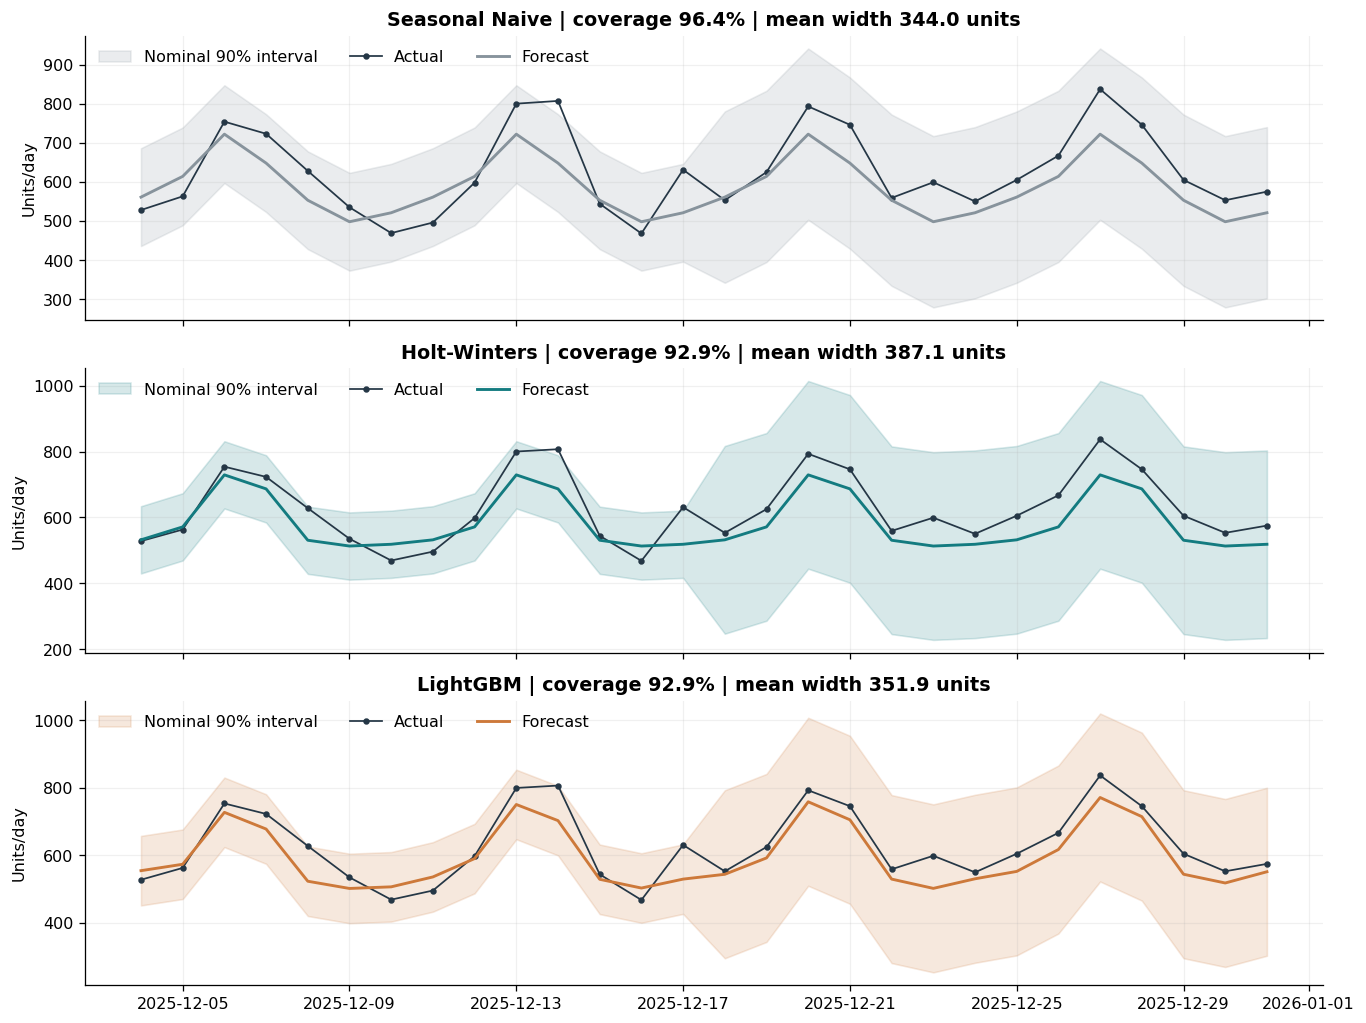

,n_days,n_covered,coverage_pct
band,,,
0,7,7,100.00
1,7,6,85.71
2,7,7,100.00
3,7,7,100.00


In [12]:
final_training, final_truth = y.iloc[:test_start].copy(), y.iloc[test_start:].copy()
final_rows, final_prediction_parts, final_fits = [], [], {}
for name in MODELS:
    fitted = fit_model(name, final_training)
    pred, pred_seconds, _ = predict_model(fitted, HORIZON)
    assert pred.index.equals(final_truth.index)
    radii = radius_table.query("model == @name").sort_values("band").used_radius.to_numpy()
    per_step_radius = np.repeat(radii, 7)
    lower = np.maximum(0.0, pred.to_numpy() - per_step_radius)
    upper = pred.to_numpy() + per_step_radius
    assert (lower <= pred).all() and (pred <= upper).all()
    final_rows.append({"model": name, "selected_before_test": name == selected_model,
                       **metric_row(final_truth, pred, final_training),
                       "nominal_coverage_pct": 100*(1-ALPHA),
                       "coverage_pct": 100*coverage(final_truth, lower, upper),
                       "mean_interval_width": interval_width(lower, upper),
                       "fit_seconds": fitted["fit_seconds"], "predict_seconds": pred_seconds,
                       "warning_count": len(fitted["fit_warnings"])})
    final_prediction_parts.append(pd.DataFrame({
        "model": name, "origin": final_training.index[-1], "date": final_truth.index,
        "horizon": np.arange(1, HORIZON+1), "actual": final_truth.to_numpy(),
        "prediction": pred.to_numpy(), "lower_90": lower, "upper_90": upper,
        "covered": (final_truth.to_numpy() >= lower) & (final_truth.to_numpy() <= upper),
    }))
    final_fits[name] = fitted
final_metrics = pd.DataFrame(final_rows)
final_predictions = pd.concat(final_prediction_parts, ignore_index=True)
display(final_metrics.round(4))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, name in zip(axes, MODELS):
    p = final_predictions.query("model == @name")
    ax.fill_between(p.date, p.lower_90, p.upper_90, color=COLORS[name], alpha=0.17, label="Nominal 90% interval")
    ax.plot(p.date, p.actual, color="#253746", marker=".", linewidth=1.1, label="Actual")
    ax.plot(p.date, p.prediction, color=COLORS[name], linewidth=1.8, label="Forecast")
    row = final_metrics.set_index("model").loc[name]
    ax.set(title=f"{name} | coverage {row.coverage_pct:.1f}% | mean width {row.mean_interval_width:.1f} units",
           ylabel="Units/day")
    ax.legend(ncol=3, frameon=False, loc="upper left")
fig.tight_layout()
save_figure(fig, "08_final_test_intervals.png")
final_metrics.to_csv(OUT / "final_test_metrics.csv", index=False)
final_predictions.to_csv(OUT / "final_test_predictions.csv", index=False)

selected_test = final_predictions.query("model == @selected_model").copy()
selected_test["band"] = ((selected_test.horizon - 1) // 7).astype(int)
coverage_by_band = selected_test.groupby("band").agg(
    n_days=("covered", "size"), n_covered=("covered", "sum"), coverage=("covered", "mean"))
display(coverage_by_band.assign(coverage_pct=lambda x: x.coverage*100).drop(columns="coverage").round(2))
print("Small sample: one covered day changes total test coverage by", round(100/HORIZON, 2), "percentage points.")

**Held-out point accuracy.** The frozen Seasonal Naive procedure records MAE
**57.75 units/day**, RMSE **68.42**,
WAPE **9.21%**, and seasonal MASE
**0.649**. This MASE is below the training seasonal-naive
scale; it does not mean the baseline beat itself. In this December test,
Holt-Winters obtains 8.66% WAPE and LightGBM
6.91%. LightGBM is the best **on this held-out period**,
which differs from the multi-origin selection verdict. This is evidence to investigate,
not permission to retrospectively choose using the test.

**Held-out uncertainty.** The selected model's 90% nominal intervals cover
**27 of 28 days (96.43%)** with mean width
**344.00 units**. Width is about
**54.9% of the test period's mean daily demand**, so this is a
conservative, fairly broad band. Both other models cover 26/28 days (92.86%);
Holt-Winters's mean width is 387.13
units and LightGBM's is 351.93 units.

All coverage estimates come from only 28 consecutive December days, with each day
changing the number by 3.57 percentage points. They do not establish calibrated
coverage over shock periods, a whole year, or every future 28-day path. No radius
was adjusted to improve these test numbers after observing them.

## 7. Model comparison and recommendation

The recommendation considers the course's decision axes as well as validation
error. Only three model families were empirically compared; no untested claim is
made about Prophet, deep learning, or a multi-series global model.

| Decision axis | Seasonal Naive | Holt-Winters | LightGBM |
|---|---|---|---|
| History needed in this project | One observed week | Repeated weekly cycles; all available history used | 56-day feature warm-up, then hundreds of training rows |
| Interpretability | Exact repeat of a known week | Level, damped trend, relative weekly effects | Gain importance and lag/calendar relationships; not causal |
| Uncertainty in this implementation | Empirical conformal wrapper | Same wrapper; no analytic interval assumed | Same wrapper; a point regressor alone has no interval |
| Compute and maintenance | Almost no fit cost | One compact model per series | Feature pipeline plus recursive inference |
| Seasonality and shocks | Repeats only the most recent week | Explicit weekly seasonality, no separate annual/shock features | Annual and weekly calendar terms; unobserved shocks remain difficult |
| Scale beyond this task | One rule per series | One fit per series | Global pooling is possible, but was not tested here |

Runtime measurements above are from this execution environment, not a production
latency guarantee. This three-year **single-series** experiment is sufficient for
a course comparison but gives few examples of moving holidays and promotions.

### Written recommendation

**For the currently specified 28-day task, use Seasonal Naive as the transparent
reference candidate in a monitored pilot, and retain LightGBM as a challenger.**
That recommendation follows the frozen five-origin validation result, rather than
promoting a more complex model merely because it won one later holdout. Seasonal
Naive uses only a known week, is directly explainable, and has negligible fitting
cost. It also has the narrowest mean interval among the three in this final test.
The serious fold-3 error means it should not be treated as a reliable automatic
ordering system without further evidence.

**History length and the number of series matter.** Three years supply 1,096 daily
rows, but only a few examples of annual and moving-shock behaviour. Initial LightGBM
training has 704 complete feature rows after a 56-day warm-up, and this implementation
fits one series. It gains none of the potential cross-series learning of a global model.
Its 6.91% final WAPE is promising, but its
28.03% selection WAPE prevents a general superiority claim.

**Interpretability and interval support also matter.** Holt-Winters offers named
level/trend/weekly components, but its residual screen detects remaining structure
and it does not beat the validation baseline. LightGBM needs a maintained feature
pipeline and a separate uncertainty wrapper; gain importance helps inspection but
does not tell a causal story. All three intervals here use the same empirical
calibration design, and none receives a guarantee from the 28-day coverage result.

**Compute is affordable for all three at this scale.** In the saved run,
Holt-Winters's mean selection fit time is
0.042 s and LightGBM's is
0.285 s, with mean 28-step inference
times of 0.011 s and
0.250 s respectively. These are
machine-specific measurements, not service-level promises. Maintenance and
validation stability currently matter more than these subsecond differences.

**Next decision gate:** add evaluation origins across a full seasonal year and,
if genuinely available before forecasting, promotion/holiday schedules. Compare
the same frozen candidates on that broader evidence, monitor coverage and width,
and reconsider a rolling window if regimes change. For a real operational rollout,
first repeat this work with real data and a business-approved error/service target.
No complex model is ready to replace the baseline on the evidence presented here.

Gain importance can be shared across correlated lags; it is not causal evidence.


,feature,gain,gain_pct
11,lag_1,2.969128e+08,47.82
14,lag_7,1.411753e+08,22.74
7,year_sin_1,2.681515e+07,4.32
0,day_of_week,2.423415e+07,3.90
17,lag_28,2.341031e+07,3.77
18,rolling_mean_7,1.552855e+07,2.50
16,lag_21,1.456782e+07,2.35
19,rolling_std_7,1.224810e+07,1.97
21,rolling_std_14,9.276715e+06,1.49
15,lag_14,8.430391e+06,1.36


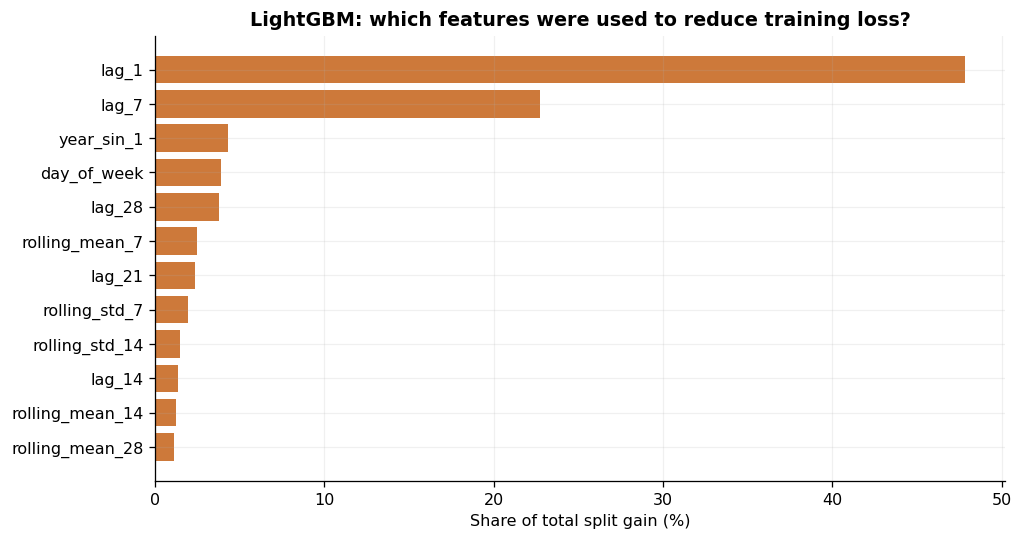

In [13]:
# A descriptive ML explanation using the model fitted before the final test.
ml_booster = final_fits["LightGBM"]["model"].booster_
importance = pd.DataFrame({"feature": final_fits["LightGBM"]["columns"],
                           "gain": ml_booster.feature_importance(importance_type="gain")})
importance = importance.sort_values("gain", ascending=False)
importance["gain_pct"] = 100*importance.gain / importance.gain.sum()
display(importance.head(12).round(2))
fig, ax = plt.subplots(figsize=(9, 4.8))
top = importance.head(12).iloc[::-1]
ax.barh(top.feature, top.gain_pct, color="#cd793a")
ax.set(title="LightGBM: which features were used to reduce training loss?",
       xlabel="Share of total split gain (%)")
fig.tight_layout()
save_figure(fig, "09_feature_importance.png")
importance.to_csv(OUT / "lightgbm_gain_importance.csv", index=False)
print("Gain importance can be shared across correlated lags; it is not causal evidence.")

### 7.1 Issue the next 28-day forecast after evaluation

After evaluating the frozen procedure, the selected family may legitimately be
refitted on **all 1,096 now-known days**. The following forecast starts after the
dataset ends, on **2026-01-01**, and ends on **2026-01-28**. There are no actual
targets for these dates in the supplied CSV, so no accuracy or coverage is claimed
for this future forecast. It is a historical-origin demonstration, not a live
forecast for today's date.

We retain the pre-test interval radii to keep the procedure simple and traceable.
Further recalibration would require additional rolling-origin evidence.

Forecast origin: 2025-12-31 | Model: Seasonal Naive


,date,model,forecast_origin,prediction,lower_90,upper_90
0,2026-01-01,Seasonal Naive,2025-12-31,605.0,480.0,730.0
1,2026-01-02,Seasonal Naive,2025-12-31,667.0,542.0,792.0
2,2026-01-03,Seasonal Naive,2025-12-31,837.0,712.0,962.0
3,2026-01-04,Seasonal Naive,2025-12-31,746.0,621.0,871.0
4,2026-01-05,Seasonal Naive,2025-12-31,605.0,480.0,730.0
5,2026-01-06,Seasonal Naive,2025-12-31,553.0,428.0,678.0
6,2026-01-07,Seasonal Naive,2025-12-31,575.0,450.0,700.0
7,2026-01-08,Seasonal Naive,2025-12-31,605.0,480.0,730.0
8,2026-01-09,Seasonal Naive,2025-12-31,667.0,542.0,792.0
9,2026-01-10,Seasonal Naive,2025-12-31,837.0,712.0,962.0


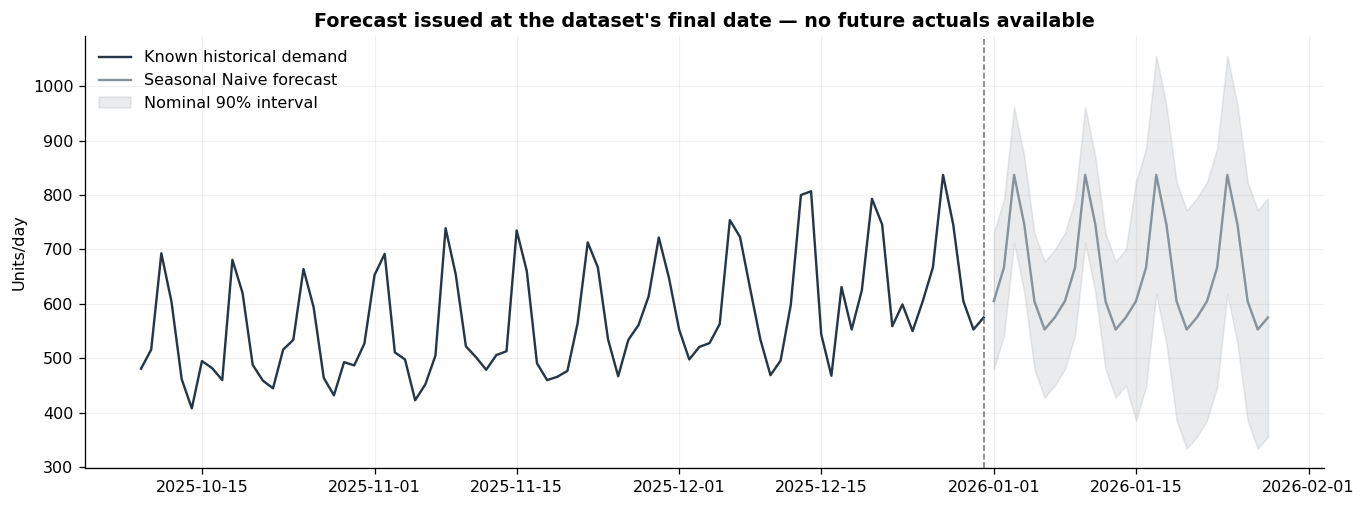

In [14]:
deployment_fit = fit_model(selected_model, y)
future_point, future_predict_seconds, _ = predict_model(deployment_fit, HORIZON)
frozen_radius = np.repeat(radius_table.query("model == @selected_model").sort_values("band").used_radius.to_numpy(), 7)
future_forecast = pd.DataFrame({"date": future_point.index, "model": selected_model,
                                "forecast_origin": y.index[-1],
                                "prediction": future_point.to_numpy(),
                                "lower_90": np.maximum(0.0, future_point.to_numpy()-frozen_radius),
                                "upper_90": future_point.to_numpy()+frozen_radius})
display(future_forecast.round(2))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(y.iloc[-84:].index, y.iloc[-84:], color="#253746", label="Known historical demand")
ax.plot(future_forecast.date, future_forecast.prediction, color=COLORS[selected_model], label=f"{selected_model} forecast")
ax.fill_between(future_forecast.date, future_forecast.lower_90, future_forecast.upper_90,
                color=COLORS[selected_model], alpha=0.18, label="Nominal 90% interval")
ax.axvline(y.index[-1], color="#777777", linestyle="--", linewidth=1)
ax.set(title="Forecast issued at the dataset's final date — no future actuals available", ylabel="Units/day")
ax.legend(frameon=False)
fig.tight_layout()
save_figure(fig, "10_next_28_days.png")
future_forecast.to_csv(OUT / "next_28_day_forecast.csv", index=False)
print("Forecast origin:", y.index[-1].date(), "| Model:", selected_model)

### 7.2 Limitations and the next practical steps

1. **Synthetic, single-series evidence.** These numbers cannot establish performance
   or financial benefit for real Riyadh stores. Test on real, permissioned data before a pilot.
2. **Unobserved shocks.** The supplied CSV has no usable future promotion or holiday
   schedule. Large demand spikes are retained as genuine forecast challenges, not removed as outliers.
3. **Limited seasonal coverage.** Five validation origins and one December final
   test are not a full-year production evaluation. Extend the origins across seasons.
4. **Uncertainty is empirical.** Dependence, model refitting, and distribution shift
   can invalidate nominal coverage. Monitor rolling coverage and interval width together.
5. **Operational choices are separate.** A forecast is not an inventory order.
   Lead times, costs, lost sales, and a chosen service level are absent from this exercise.
6. **New data can change the choice.** Recompare models after structural change;
   test a rolling window and known future drivers only when justified and available.

### Submission coverage

| Requirement | Location in this notebook |
|---|---|
| Decomposition, ACF/PACF, ADF, and interpretation | Section 1 |
| Classical model, parameter rationale, Ljung-Box | Section 2 |
| ML, lag/rolling/calendar features, recursive leakage controls | Section 3 |
| At least three chronological folds and justified window | Section 4: five comparison folds |
| MAE/RMSE and scale-free metrics | Sections 4–5: WAPE and seasonal MASE |
| Interval, reported coverage and width | Section 6: nominal 90% with separate final scoring |
| Written recommendation across decision axes | Section 7 and its saved-run recommendation |
| Real outputs and a runnable single notebook | This executed `.ipynb` |

GitHub account, actual cohort dates, repository publication, and ongoing commits
must be completed under the trainee's real account. The companion files explain
those steps and provide documentation; no publication or submission is fabricated.

## 8. Export, reproducibility, and integrity checks

Running this cell writes CSV tables, figures, configuration, and a machine-readable
summary to `capstone_outputs/`, then packages them in `capstone_results.zip`.
The last optional cell downloads that archive in Colab. No output file is needed
to execute a later code cell; the notebook remains self-contained.

In [15]:
PACKAGE_VERSIONS = {p: metadata.version(p) for p in
                    ["numpy", "pandas", "scipy", "scikit-learn", "statsmodels", "lightgbm", "matplotlib"]}
config = {"author": "Abdulwahab Mohammed Ali Alnassar",
          "programme": "SDAIA Academy — Time Series Forecasting for AI Systems",
          "cohort_dates": "Not supplied; trainee must enter actual dates before submission",
          "source_commit": SOURCE_COMMIT, "source_url": SOURCE_URL,
          "original_sha256": ORIGINAL_DATA_SHA256, "subset_sha256": SUBSET_SHA256,
          "data_type": "synthetic", "region": "Riyadh", "category": "Grocery",
          "horizon": HORIZON, "period": PERIOD, "selection_folds": N_SELECTION_FOLDS,
          "calibration_folds": N_CALIBRATION_FOLDS, "alpha": ALPHA, "seed": SEED,
          "window": "expanding", "complexity_tolerance_relative": COMPLEXITY_TOLERANCE,
          "lightgbm_parameters": LGBM_PARAMS, "selected_before_calibration": selected_model,
          "runtime": {"python": sys.version, "platform": platform.platform(), "packages": PACKAGE_VERSIONS}}
results_summary = {"selected_model": selected_model, "data_audit": data_audit.to_dict("records"),
                   "partitions": partition_table.to_dict("records"), "eda": eda_summary,
                   "adf": adf_table.to_dict("records"),
                   "ljung_box": lb.reset_index().to_dict("records"),
                   "hw_parameters": hw_parameters,
                   "selection": selection_summary.to_dict("records"),
                   "final_test": final_metrics.to_dict("records"),
                   "radii": radius_table.to_dict("records"),
                   "future_start": str(future_forecast.date.min().date()),
                   "future_end": str(future_forecast.date.max().date()),
                   "recursion_checks_passed": True}
(OUT / "run_config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
(OUT / "results_summary.json").write_text(json.dumps(results_summary, indent=2, ensure_ascii=False), encoding="utf-8")
(OUT / "package_versions.txt").write_text("\n".join(f"{p}=={v}" for p, v in PACKAGE_VERSIONS.items())+"\n")

checks = {
    "Dataset checksum, schema, dates and values validated": True,
    "Five comparison folds for every model": len(selection_scores) == 15,
    "Six later calibration origins for every model": len(calibration_scores) == 18,
    "No final-test observations in calibration predictions": calibration_predictions.date.max() < final_truth.index.min(),
    "At least one classical and one ML model evaluated": {"Holt-Winters", "LightGBM"}.issubset(set(final_metrics.model)),
    "Both scale-dependent and scale-free metrics reported": {"MAE", "RMSE", "WAPE_pct", "MASE_s7"}.issubset(final_metrics.columns),
    "Interval coverage and width reported for every model": final_metrics[["coverage_pct", "mean_interval_width"]].notna().all().all(),
    "Future forecast begins after all observed dates": future_forecast.date.min() > y.index.max(),
    "Future forecast contains exactly 28 dates": len(future_forecast) == HORIZON,
}
assert all(checks.values()), checks
integrity_checks = pd.DataFrame({"check": checks.keys(), "passed": [bool(v) for v in checks.values()]})
display(integrity_checks)
integrity_checks.to_csv(OUT / "integrity_checks.csv", index=False)
archive = Path(shutil.make_archive("capstone_results", "zip", root_dir=OUT)).resolve()
print("All integrity checks passed.")
print("Results archive:", archive.name)
print("Selected model:", selected_model)
display(final_metrics.loc[final_metrics.selected_before_test].round(3))

All integrity checks passed.
Results archive: capstone_results.zip
Selected model: Seasonal Naive


,check,passed
0,"Dataset checksum, schema, dates and values val...",True
1,Five comparison folds for every model,True
2,Six later calibration origins for every model,True
3,No final-test observations in calibration pred...,True
4,At least one classical and one ML model evaluated,True
5,Both scale-dependent and scale-free metrics re...,True
6,Interval coverage and width reported for every...,True
7,Future forecast begins after all observed dates,True
8,Future forecast contains exactly 28 dates,True


,model,selected_before_test,MAE,RMSE,WAPE_pct,MASE_s7,nominal_coverage_pct,coverage_pct,mean_interval_width,fit_seconds,predict_seconds,warning_count
0,Seasonal Naive,True,57.75,68.424,9.21,0.649,90.0,96.429,344.0,0.0,0.001,0


In [16]:
# @title Optional: download the generated results archive
DOWNLOAD_RESULTS = False  # Change to True to trigger a download in Google Colab.
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(str(archive))
    except ImportError:
        display(FileLink(str(archive)))
else:
    print("Results archive is ready. Set DOWNLOAD_RESULTS = True to download in Colab.")

Results archive is ready. Set DOWNLOAD_RESULTS = True to download in Colab.


## References

- [Course capstone brief](https://mohammadyusif.github.io/time-series-forecasting-ai-systems/capstone.html)
- [Course source and data](https://github.com/MohammadYusif/time-series-forecasting-ai-systems)
- [Course model-comparison decision axes](https://mohammadyusif.github.io/time-series-forecasting-ai-systems/day3/06_model_comparison.html)
- [statsmodels Holt-Winters API](https://www.statsmodels.org/stable/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html)
- [statsmodels ADF API](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)
- [statsmodels Ljung-Box API](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html)
- [LightGBM Python API](https://lightgbm.readthedocs.io/en/stable/Python-API.html)
- [SDAIA Academy](https://github.com/SDAIAAcademy)

The notebook computes its own scores from the pinned snapshot. Course example
benchmark numbers are not treated as results of this project.